**Analytics in Business Capstone Project**

# Report: Heat Smart Orkney

**Group B**

For our client Kaluza, we quantify Orkney wind curtailment from turbine telemetry, estimate how much residential
demand response (DR) can absorb at different enrolment levels, and translate the opportunity
into a monetisation and break-even view for Kaluza's Heat Smart Orkney (HSO) programme.

> **Research question:** <br>
> How much Orkney wind curtailment can be mitigated through residential demand response, and what economic value does this unlock for households and the Heat Smart Orkney programme?
<br>
<br>
> **Subsidiary questions:**
>- (Q1) Annual curtailed energy across Orkney
>- (Q2) Curtailment reduction potential as a function of DR penetration
>- (Q3) Household participation required to deliver that DR capacity
<br>
<br>


# Summary

This report investigates whether residential demand response through Kaluza’s Heat Smart Orkney (HSO) platform can meaningfully reduce wind curtailment on the Orkney Islands, where renewable generation is constrained by limited export capacity to mainland Great Britain. After cleaning and analysing operational wind and demand data, the study validated a non-linear turbine power curve to estimate unconstrained generation and quantify annual curtailed energy. The analysis estimates that Orkney curtails approximately **76.86 GWh of wind energy per year**, confirming that curtailment is a significant technical and economic issue. A flexible residential heating demand model was then developed to evaluate how much of this curtailed energy could be recovered through smart electric heating. Under a full-enrolment scenario, the HSO framework avoids approximately **267.3 MWh/year**, corresponding to only **0.35%** of total curtailed energy; a 25% penetration scenario corresponds to roughly **2,596 participating homes** and around **78.7 MWh/year** avoided. Although the results support the technical feasibility of residential flexibility, they also show that residential demand response alone cannot materially reduce system-wide curtailment levels. The business analysis further indicates that Kaluza’s direct revenues remain limited under current assumptions (approximately **£3,007/year at full penetration**) unless supported by subsidies, grid incentives or partnerships with wind operators. Overall, the report concludes that the strategic value of Heat Smart Orkney lies less in eliminating curtailment at scale and more in demonstrating the operational and commercial viability of flexible demand orchestration within future smart-grid systems.


# Introduction

The transition toward low-carbon electricity systems requires not only large-scale renewable generation, but also sufficient flexibility to absorb intermittent production. On the Orkney Islands, wind generation capacity has expanded rapidly due to excellent wind resources, yet the local electricity network remains constrained by limited export capacity to mainland Great Britain. In particular, a **40 MW subsea cable** caps the amount of electricity that can be transmitted off the islands at any given time. During periods of strong wind and relatively low local demand, total generation can therefore exceed the combined capacity of local consumption and exports.

To preserve network stability under these conditions, the distribution network operator reduces the operating setpoints of wind turbines, forcing generators to produce less electricity than would otherwise be available from the wind resource. This process, known as **curtailment**, leads to renewable energy being effectively wasted: curtailed electricity cannot be sold on wholesale markets and does not contribute to carbon displacement. Curtailment therefore represents both an economic loss for generators and a missed opportunity for decarbonisation.

Kaluza’s **Heat Smart Orkney (HSO)** project addresses this challenge through a demand response strategy based on flexible residential electric heating. Rather than reducing wind generation during constrained periods, HSO seeks to dynamically increase electricity demand by activating enrolled household heating systems whenever excess renewable generation is available. By shifting electricity consumption toward periods of surplus wind production, the project aims to convert otherwise-curtailed renewable energy into useful thermal demand.

This report investigates the scale, temporal dynamics and potential recoverability of curtailed wind energy in Orkney, with the objective of assessing the business value of residential demand response in this context. The analysis is guided by the following hypotheses:

| Hypothesis | Validation Approach |
| :--- | :--- |
| Annual fleet curtailment is material (on the order of 10+ GWh) | Energy balance analysis |
| Curtailment is temporally concentrated during windy, low-demand periods | Exploratory data analysis and time-series analysis |
| A bounded but meaningful share of curtailed energy can be recovered through residential demand response | Flexible demand saturation modelling |
| Wind turbine power output follows a non-linear saturating relationship with wind speed, capped near rated capacity (≈900 kW) | Empirical power curve validation |

To answer these questions, the report first performs data cleaning and exploratory analysis of wind generation, curtailment signals and operational behaviour. A validated turbine power curve is then constructed to estimate unconstrained production and quantify curtailment levels. Building on this foundation, a flexible residential heating demand model is developed and matched against periods of excess renewable generation in order to estimate the proportion of curtailed energy that could realistically be absorbed by demand response. Finally, the operational findings are translated into a business and energy-system perspective, highlighting the economic and environmental implications of smart flexible demand in constrained renewable networks.


# Technologies and techniques 

Every headline number in this report flows from the constants below. For each parameter we state
**what it means in the model** and **where it comes from** (client data, technical brief, FAQ
or a consultant assumption we made). Post-2017 statistics are not used, consistent with the
2017 scenario.

| Parameter | Value (central) | What it means | Source / rationale |
|-----------|-----------------|---------------|-------------------|
| `HEADLINE_YEAR` | 2017 | Calendar year for turbine curtailment totals and demand matching. | Aligns with `Residential_demand.csv` (2017 only). Turbine telemetry is filtered to 2017 even though the file spans 2015–2018 (`energy_brief.pdf`). |
| `NAMEPLATE_KW` | 900 | Maximum rated output of the exemplar turbine in the dataset. | Stated in case brief and `Turbine_telemetry.csv` (setpoint tops out at 900 kW). |
| `NAMEPLATE_FRAC` | 0.99 | Setpoint below this fraction of nameplate ⇒ **curtailed regime** (network cap active). | Modelling convention from `energy_brief.pdf` (setpoint as curtailment signal). Threshold is slightly below 900 kW to avoid numerical edge cases. |
| `N_TURBINES` | 500 | Scales single-turbine results to an Orkney-wide fleet. | FAQ invites 500 or a 2017-cited count. |
| `FLEET_CORRELATION` | 1.0 | Multiplier if turbines are not statistically independent. | FAQ: scale one average turbine; correlation = 1 assumes identical machines and weather exposure. |
| `STORM_MEAN_MS` / `STORM_PEAK_MS` | 25 / 30 | 10-min mean wind >25 m/s or gust >30 m/s ⇒ **storm shutdown** (excluded from curve fit and curtailment sums). | `HSO FAQ.txt` (storm control per turbine datasheet behaviour). |
| `CUT_IN_MS` | 3.0 | Minimum wind for generation; used to classify **downtime** (zero power with wind above cut-in). | Approximate from EDA on telemetry; not critical per FAQ. |
| `N_HOUSEHOLDS_ORKNEY` | 10,385 | Denominator for DR **penetration** and scaler from sample mean kW to island demand. | `HSO FAQ.txt` (approximate Orkney household count). Distinct from `N_households` in the demand file (~5,400 sample). |
| `DEMAND_ANOMALY_MAD_Z` | 4.5 | Robust z-score threshold on daily residuals around a robust linear trend (`N_households`). | Consultant rule to flag anomalous days (including short spikes) without excluding full months. |
| `F_FLEX` | 0.40 | Share of **variable** residential demand that smart heating can shift for DR. | Consultant assumption within FAQ range (best/worst case via household count); central 40% with sensitivity 25–55%. `energy_brief.pdf` discusses shiftable heating load. |
| `AVAILABILITY` | 0.70 | Fraction of enrolled homes **online and dispatchable** when curtailment occurs. | Consultant assumption (devices offline, opt-out, comfort limits). Sensitivity 50–90%. |
| `WHOLESALE_GBP_MWH` | 45 | £ value per MWh of avoided curtailment (wholesale proxy). | **2017-era** GB wholesale order-of-magnitude (£35–55/MWh band). |
| `KALUZA_VALUE_SHARE` | 0.333 | Kaluza’s share of gross avoided-curtailment value after consumer/generator split. | Illustrative revenue-share for business case (`HSO FAQ.txt`: negotiate splits with wind farms and consumers). |
| `HUB_GBP` | 100 | Retrofit control hub cost **per radiator** controlled. | `energy_brief.pdf` / FAQ (~£100 per device). |
| `RADIATORS_PER_HOME` | 2 | Number of radiators/heating zones controlled per home. | Consultant assumption (typical storage-heater home). |
| `HEATER_GBP` | 300 | Quantum heater hardware cost per home (2017 money). | FAQ: ~£600 in 2018 list price, **halved** for 2017. |
| `SUBSIDY_LEVELS` | 25–100% | Share of upfront capex paid by programme/government in break-even scenarios. | `HSO FAQ.txt` (explore 25%, 50%, 75%, 100% subsidies). |

**Data sources (fixed inputs, not tunable assumptions):**

- `data/Turbine_telemetry.csv` — one 900 kW turbine, ~1 min resolution (`Formatting Rules` / FAQ: scale to fleet).
- `data/Residential_demand.csv` — Kaluza proxy aggregate, 30 min, `Demand_mean_kw` per sample household.


In [ ]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

from IPython.display import display
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from scipy.interpolate import PchipInterpolator
from scipy import stats

# Plot style (readable for marking / export)
plt.rcParams.update({
    "figure.figsize": (10, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})

DATA_DIR = Path("data")
HEADLINE_YEAR = 2017

# --- Physical & fleet ---
NAMEPLATE_KW = 900
NAMEPLATE_FRAC = 0.99
N_TURBINES = 500
FLEET_CORRELATION = 1.0
STORM_MEAN_MS = 25.0
STORM_PEAK_MS = 30.0
CUT_IN_MS = 3.0  # approximate; refined from data in EDA

# --- Orkney households ---
N_HOUSEHOLDS_ORKNEY = 10_385
DEMAND_ANOMALY_MAD_Z = 4.5  # robust z-score threshold for daily N_households anomalies

# --- DR flexibility ---
F_FLEX = 0.40
AVAILABILITY = 0.70
F_FLEX_LOW, F_FLEX_HIGH = 0.25, 0.55
AVAIL_LOW, AVAIL_HIGH = 0.50, 0.90

# --- Economics (2017 planning scenario) ---
WHOLESALE_GBP_MWH = 45.0
WHOLESALE_LOW, WHOLESALE_HIGH = 35.0, 55.0
KALUZA_VALUE_SHARE = 0.333
HUB_GBP = 100.0
RADIATORS_PER_HOME = 2
HEATER_GBP = 300.0
SUBSIDY_LEVELS = [0.25, 0.50, 0.75, 1.00]
PENETRATION_GRID = [0, 100, 250, 500, 1000, 2000, 3000, 5000, 7500, 10000, N_HOUSEHOLDS_ORKNEY]
DR_PENETRATION_TARGETS = [0.10, 0.25, 0.50]  # share of Orkney households enrolled

# --- Value-pool splits (illustrative four-actor models, must sum to 1.0) ---
SHARE_HOUSEHOLD = 0.40   # discounted energy / bill savings
SHARE_WIND = 0.25        # royalty to generators
SHARE_KALUZA = 0.25      # platform + install margin (aligned with KALUZA_VALUE_SHARE order of magnitude)
SHARE_GRID = 0.10        # balancing / constraint payment
HOUSEHOLD_DISCOUNT_GBP_MWH = 20.0  # £ benefit per MWh shifted to curtailed-wind slots
WIND_ROYALTY_ADMIN_GBP_YR = 5_000   # minimum annual fee wind farm pays Kaluza to participate
GRID_VALUE_GBP_MWH = 8.0             # implied £/MWh for constraint relief (illustrative)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

assumptions = pd.DataFrame([
    {"parameter": "headline_year", "value": HEADLINE_YEAR,
     "meaning": "Analysis year for annual curtailment and DR matching",
     "source": "Residential_demand.csv coverage; energy_brief.pdf"},
    {"parameter": "nameplate_kw", "value": NAMEPLATE_KW,
     "meaning": "Rated max power of exemplar turbine",
     "source": "Case dataset + energy_brief.pdf"},
    {"parameter": "nameplate_frac", "value": NAMEPLATE_FRAC,
     "meaning": "Setpoint threshold defining curtailed regime",
     "source": "energy_brief.pdf (setpoint semantics)"},
    {"parameter": "n_turbines", "value": N_TURBINES,
     "meaning": "Fleet multiplier for Orkney-wide Q1 scaling",
     "source": "energy_brief.pdf (>500 turbines); HSO FAQ (suggest 500)"},
    {"parameter": "fleet_correlation", "value": FLEET_CORRELATION,
     "meaning": "Correlation adjustment on fleet scale",
     "source": "HSO FAQ (scale average turbine); sensitivity in Appendix"},
    {"parameter": "storm_mean_ms", "value": STORM_MEAN_MS,
     "meaning": "10-min mean wind limit for storm exclusion",
     "source": "HSO FAQ.txt"},
    {"parameter": "storm_peak_ms", "value": STORM_PEAK_MS,
     "meaning": "Peak gust limit for storm exclusion",
     "source": "HSO FAQ.txt"},
    {"parameter": "cut_in_ms", "value": CUT_IN_MS,
     "meaning": "Cut-in wind for downtime classification",
     "source": "EDA on telemetry (approximate)"},
    {"parameter": "n_households_orkney", "value": N_HOUSEHOLDS_ORKNEY,
     "meaning": "Orkney households for penetration % and demand scaling",
     "source": "HSO FAQ.txt (~10,385)"},
    {"parameter": "demand_anomaly_mad_z", "value": DEMAND_ANOMALY_MAD_Z,
     "meaning": "Robust z-score threshold for daily sample-size anomaly detection",
     "source": "Consultant rule based on robust linear-trend residuals"},
    {"parameter": "f_flex", "value": F_FLEX,
     "meaning": "Fraction of variable demand dispatchable by DR heating",
     "source": "Consultant assumption; FAQ best/worst framing"},
    {"parameter": "availability", "value": AVAILABILITY,
     "meaning": "Share of enrolled homes dispatchable when needed",
     "source": "Consultant assumption; sensitivity 0.5–0.9"},
    {"parameter": "wholesale_gbp_mwh", "value": WHOLESALE_GBP_MWH,
     "meaning": "£/MWh for valuing avoided curtailment",
     "source": "2017 wholesale planning range (£35–55); central £45"},
    {"parameter": "kaluza_value_share", "value": KALUZA_VALUE_SHARE,
     "meaning": "Kaluza revenue share of avoided-curtailment value",
     "source": "Illustrative business case (HSO FAQ revenue-sharing)"},
    {"parameter": "hub_gbp", "value": HUB_GBP,
     "meaning": "Smart hub cost per controlled radiator",
     "source": "energy_brief.pdf / FAQ (~£100)"},
    {"parameter": "radiators_per_home", "value": RADIATORS_PER_HOME,
     "meaning": "Radiators controlled per household (capex)",
     "source": "Consultant assumption (typical install)"},
    {"parameter": "heater_gbp", "value": HEATER_GBP,
     "meaning": "Quantum heater capex per home (2017)",
     "source": "FAQ: ~£600 in 2018, scaled ×0.5 for 2017"},
    {"parameter": "f_flex_sensitivity", "value": f"{F_FLEX_LOW} – {F_FLEX_HIGH}",
     "meaning": "Low / high DR flexibility scenarios",
     "source": "Consultant stress test"},
    {"parameter": "availability_sensitivity", "value": f"{AVAIL_LOW} – {AVAIL_HIGH}",
     "meaning": "Low / high device availability scenarios",
     "source": "Consultant stress test"},
])
# display(assumptions)

# --- DCF / business-model engine (illustrative, scenario-grade 2017 proxy) ---
DISCOUNT_RATE = 0.08              # Kaluza WACC for the DCF
HORIZON_YEARS = 10               # appraisal horizon (years)
OPEX_PER_HOME_YR = 12.0          # platform ops, comms, dispatch, metering (£/home/yr)
CHURN_RATE = 0.03                # annual attrition -> replacement-capex drag
PEAK_DISPATCH_KW_PER_HOME = 2.0  # controllable heating load per home (pre-availability)
CAPACITY_GBP_MW_YR = 25_000.0    # grid/DNO availability payment (£/MW/yr)
UTILISATION_GBP_MWH = 200.0      # flexibility utilisation payment (£/MWh dispatched)
ASSET_FLEX_MULT = 3.0            # multi-asset (EV+battery+hot water) vs heating-only capacity
FREQ_RESPONSE_GBP_MW_YR = 60_000.0    # dynamic frequency response availability (£/MW/yr)
CAPACITY_MARKET_GBP_MW_YR = 45_000.0  # derated capacity-market clearing (£/MW/yr)
ASSET_INTEGRATION_CAPEX = 200.0  # incremental per-home capex for EV/battery integration

assumptions = pd.concat([assumptions, pd.DataFrame([
    {"parameter": "discount_rate", "value": DISCOUNT_RATE,
     "meaning": "WACC for 10-yr DCF of the business models", "source": "Consultant assumption (infrastructure WACC)"},
    {"parameter": "horizon_years", "value": HORIZON_YEARS,
     "meaning": "DCF appraisal horizon", "source": "Consultant assumption (asset life)"},
    {"parameter": "opex_per_home_yr", "value": OPEX_PER_HOME_YR,
     "meaning": "Annual platform/ops cost per enrolled home", "source": "Illustrative SaaS + ops estimate"},
    {"parameter": "churn_rate", "value": CHURN_RATE,
     "meaning": "Annual attrition -> replacement-capex drag", "source": "Illustrative"},
    {"parameter": "peak_dispatch_kw_per_home", "value": PEAK_DISPATCH_KW_PER_HOME,
     "meaning": "Controllable heating load per home before availability", "source": "Quantum heater rating (illustrative)"},
    {"parameter": "capacity_gbp_mw_yr", "value": CAPACITY_GBP_MW_YR,
     "meaning": "Grid/DNO availability payment", "source": "DNO flexibility market range (illustrative)"},
    {"parameter": "utilisation_gbp_mwh", "value": UTILISATION_GBP_MWH,
     "meaning": "Flexibility utilisation payment per MWh", "source": "DNO flexibility utilisation (illustrative)"},
    {"parameter": "asset_flex_mult", "value": ASSET_FLEX_MULT,
     "meaning": "Multi-asset vs heating-only dispatchable capacity", "source": "Scenario assumption (EV+battery+hot water)"},
    {"parameter": "freq_response_gbp_mw_yr", "value": FREQ_RESPONSE_GBP_MW_YR,
     "meaning": "Frequency-response availability payment", "source": "GB ancillary services (illustrative)"},
    {"parameter": "capacity_market_gbp_mw_yr", "value": CAPACITY_MARKET_GBP_MW_YR,
     "meaning": "Derated capacity-market clearing price", "source": "GB capacity market (illustrative)"},
    {"parameter": "asset_integration_capex", "value": ASSET_INTEGRATION_CAPEX,
     "meaning": "Incremental per-home capex for EV/battery integration", "source": "Illustrative"},
])], ignore_index=True)


## 1. Methods

All logic lives in a single notebook so Kaluza's analytics team can replicate and extend the work
without external modules. Below we define each step:

| Step | Function(s) | Purpose |
|------|-------------|---------|
| Load / clean | `load_*`, `clean_*` | Parse CSVs, flag regimes, handle gaps |
| Power curve | `fit_binned_power_curve`, `validate_power_curve` | Wind → counterfactual kW |
| Curtailment | `attach_potential_and_curtailment`, `annual_curtailment_mwh` | Lost MWh |
| Flex demand | `build_flexible_demand` | Shiftable heating kW |
| DR match | `supply_demand_match` | Avoided MWh vs enrolment |
| Economics | `value_pool_gbp`, `split_pool`, `break_even_households` | Business case |


In [2]:
def load_turbine(path=DATA_DIR / "Turbine_telemetry.csv"):
    # Load turbine telemetry; parse timestamps.
    df = pd.read_csv(path, parse_dates=["Timestamp"])
    df = df.sort_values("Timestamp").reset_index(drop=True)
    return df


def load_demand(path=DATA_DIR / "Residential_demand.csv"):
    # Load half-hourly residential demand proxy.
    df = pd.read_csv(path, parse_dates=["Timestamp"])
    df = df.sort_values("Timestamp").reset_index(drop=True)
    return df


def forward_interval_hours(ts):
    # Hours until next timestamp; cap at 1 h for gaps.
    delta = ts.shift(-1) - ts
    hours = delta.dt.total_seconds() / 3600.0
    return hours.fillna(hours.median()).clip(upper=1.0)


def clean_turbine(df, year=HEADLINE_YEAR):
    # Filter to headline year; drop NA; add interval hours and storm flags.
    ledger = {}
    out = df.copy()
    ledger["rows_in"] = len(out)

    out = out[(out["Timestamp"] >= f"{year}-01-01") & (out["Timestamp"] < f"{year + 1}-01-01")]
    ledger[f"rows_{year}"] = len(out)

    before = len(out)
    out = out.dropna(subset=["Power_kw", "Setpoint_kw", "Wind_ms"])
    ledger["rows_dropped_na"] = before - len(out)

    out["dt_h"] = forward_interval_hours(out["Timestamp"])
    out["wind_roll10m"] = out["Wind_ms"].rolling(10, min_periods=1).mean()
    out["is_storm"] = (out["wind_roll10m"] > STORM_MEAN_MS) | (out["Wind_ms"] > STORM_PEAK_MS)
    out["is_downtime"] = (out["Power_kw"] <= 0) & (out["Wind_ms"] >= CUT_IN_MS)
    out["is_curtailed_regime"] = out["Setpoint_kw"] < NAMEPLATE_KW * NAMEPLATE_FRAC
    out["overshoot"] = out["Power_kw"] > out["Setpoint_kw"] + 5

    ledger["storm_rows"] = int(out["is_storm"].sum())
    ledger["downtime_rows"] = int(out["is_downtime"].sum())
    ledger["curtailed_regime_rows"] = int(out["is_curtailed_regime"].sum())
    ledger["overshoot_rows"] = int(out["overshoot"].sum())
    return out, pd.Series(ledger, name="count")


def clean_demand(df, year=HEADLINE_YEAR, mad_z=DEMAND_ANOMALY_MAD_Z):
    # Restrict to analysis year, then detect anomalous dates from daily sample-size residuals.
    out = df.copy()
    out = out[(out["Timestamp"] >= f"{year}-01-01") & (out["Timestamp"] < f"{year + 1}-01-01")].copy()
    out["date"] = out["Timestamp"].dt.floor("D")

    daily_n = out.groupby("date")["N_households"].median().sort_index()
    t = np.arange(len(daily_n), dtype=float)

    if len(daily_n) >= 3:
        slope, intercept, _, _ = stats.theilslopes(daily_n.values.astype(float), t, 0.95)
    else:
        slope, intercept = 0.0, float(daily_n.median()) if len(daily_n) else 0.0

    trend = pd.Series(intercept + slope * t, index=daily_n.index)
    resid = daily_n - trend

    mad = np.median(np.abs(resid - np.median(resid)))
    sigma = 1.4826 * mad if mad > 0 else np.nan

    if np.isfinite(sigma) and sigma > 0:
        z = resid.abs() / sigma
        anomaly_dates = z[z > mad_z].index
    else:
        z = pd.Series(0.0, index=daily_n.index)
        anomaly_dates = pd.Index([])

    out["trend_n_households_day"] = out["date"].map(trend.to_dict())
    out["resid_n_households_day"] = out["date"].map(resid.to_dict())
    out["z_n_households_day"] = out["date"].map(z.to_dict())
    out["is_anomaly_day"] = out["date"].isin(anomaly_dates)
    out["month"] = out["Timestamp"].dt.month
    out["demand_total_kw"] = out["Demand_mean_kw"] * N_HOUSEHOLDS_ORKNEY

    ledger = {
        "rows_in": len(out),
        "anomaly_rows": int(out["is_anomaly_day"].sum()),
        "anomaly_days": int(len(anomaly_dates)),
        "anomaly_dates_head": ", ".join(str(d.date()) for d in anomaly_dates[:8]),
        "n_households_min": out["N_households"].min(),
        "n_households_max": out["N_households"].max(),
        "daily_z_max": float(z.max()) if len(z) else 0.0,
        "trend_slope_per_day": float(slope),
    }

    out_clean = out[~out["is_anomaly_day"]].copy()
    ledger["rows_after_anomaly_exclusion"] = len(out_clean)
    return out, out_clean, pd.Series(ledger, name="count")


def fit_binned_power_curve(df, n_bins=35, min_bin_count=50):
    # Monotone binned-mean wind-to-power curve on normal regime rows.
    normal = df[~df["is_storm"] & ~df["is_downtime"] & ~df["is_curtailed_regime"]].copy()
    normal = normal[(normal["Setpoint_kw"] >= NAMEPLATE_KW * NAMEPLATE_FRAC)]

    wind = normal["Wind_ms"].values
    power = normal["Power_kw"].values
    bins = np.linspace(max(0, wind.min()), min(wind.max(), 25), n_bins + 1)
    rows = []
    xs, ys = [], []
    for i in range(len(bins) - 1):
        lo, hi = bins[i], bins[i + 1]
        mask = (wind >= lo) & (wind < hi)
        if mask.sum() < min_bin_count:
            continue
        xs.append(normal.loc[mask, "Wind_ms"].mean())
        ys.append(normal.loc[mask, "Power_kw"].mean())
    xs = np.array(xs)
    ys = np.clip(np.array(ys), 0, NAMEPLATE_KW)
    # enforce non-decreasing then cap
    ys = np.maximum.accumulate(ys)
    interp = PchipInterpolator(xs, ys, extrapolate=True)

    def predict(w):
        w = np.asarray(w, dtype=float)
        p = interp(w)
        return np.clip(p, 0, NAMEPLATE_KW)

    diag = pd.DataFrame({"wind_ms": xs, "mean_power_kw": ys, "bin_count": [min_bin_count] * len(xs)})
    return predict, normal, diag


def validate_power_curve(normal_df, predict_fn):
    # Return error metrics and residual frame for normal regime.
    pred = predict_fn(normal_df["Wind_ms"].values)
    actual = normal_df["Power_kw"].values
    resid = actual - pred
    metrics = {
        "mae_kw": np.mean(np.abs(resid)),
        "rmse_kw": np.sqrt(np.mean(resid ** 2)),
        "r2": 1 - np.sum(resid ** 2) / np.sum((actual - actual.mean()) ** 2),
    }
    out = normal_df[["Timestamp", "Wind_ms", "Power_kw"]].copy()
    out["pred_kw"] = pred
    out["residual_kw"] = resid
    return metrics, out


def attach_potential_and_curtailment(df, predict_fn):
    # Per-row potential power and curtailed power (kW).
    out = df.copy()
    out["potential_kw"] = predict_fn(out["Wind_ms"].values)
    # Curtailment only when setpoint regime active and not storm/downtime
    active = out["is_curtailed_regime"] & ~out["is_storm"] & ~out["is_downtime"]
    out["curtailed_kw"] = 0.0
    # Lost output vs wind potential (beta / brief counterfactual; not setpoint-minus-actual)
    out.loc[active, "curtailed_kw"] = np.maximum(
        0, out.loc[active, "potential_kw"] - out.loc[active, "Power_kw"]
    )
    out["curtailed_kwh"] = out["curtailed_kw"] * out["dt_h"]
    return out


def annual_curtailment_mwh(df):
    return df["curtailed_kwh"].sum() / 1000.0


def bootstrap_annual_ci(df, year=HEADLINE_YEAR, n_boot=300):
    # Day-level bootstrap of annual MWh for one turbine.
    daily = df.groupby(df["Timestamp"].dt.date)["curtailed_kwh"].sum() / 1000.0
    days = daily.values
    rng = np.random.default_rng(RANDOM_SEED)
    boots = []
    for _ in range(n_boot):
        sample = rng.choice(days, size=len(days), replace=True)
        boots.append(sample.sum())
    lo, hi = np.percentile(boots, [5, 95])
    return lo, hi


def aggregate_turbine_to_30min(df):
    # Sum curtailed energy to 30-min bins aligned to demand.
    g = df.set_index("Timestamp").resample("30min")
    agg = g.agg(
        curtailed_kwh=("curtailed_kwh", "sum"),
        curtailed_kw_mean=("curtailed_kw", "mean"),
        power_kw_mean=("Power_kw", "mean"),
        setpoint_kw_mean=("Setpoint_kw", "mean"),
    ).reset_index()
    return agg


def build_flexible_demand(demand_clean, f_flex=F_FLEX):
    # Baseline = rolling 24h minimum per household; flexible = f_flex * headroom above it.
    d = demand_clean.copy()
    d["baseline_kw"] = d["Demand_mean_kw"].rolling(48, min_periods=12).min()
    d["variable_kw"] = (d["Demand_mean_kw"] - d["baseline_kw"]).clip(lower=0)
    d["flexible_kw_per_hh"] = f_flex * d["variable_kw"]
    d["flexible_kw_island"] = d["flexible_kw_per_hh"] * N_HOUSEHOLDS_ORKNEY
    return d


def supply_demand_match(supply_30, demand_flex, n_enrolled, availability=AVAILABILITY):
    # Half-hourly avoided curtailment for given enrolled households.
    d = demand_flex.merge(supply_30, on="Timestamp", how="inner")
    fleet_factor = N_TURBINES * FLEET_CORRELATION
    d["curtailed_kwh_fleet"] = d["curtailed_kwh"] * fleet_factor
    d["dr_kw"] = d["flexible_kw_per_hh"] * n_enrolled * availability
    d["dr_kwh"] = d["dr_kw"] * 0.5  # 30-min interval
    d["avoided_kwh"] = np.minimum(d["curtailed_kwh_fleet"], d["dr_kwh"])
    annual_avoided_mwh = d["avoided_kwh"].sum() / 1000.0
    annual_curtailed_mwh = d["curtailed_kwh_fleet"].sum() / 1000.0
    return d, annual_avoided_mwh, annual_curtailed_mwh


def households_for_target(annual_curtailed_mwh, target_frac, curve_df):
    # Interpolate households needed for target recovery fraction.
    target_mwh = target_frac * annual_curtailed_mwh
    sub = curve_df.sort_values("n_households")
    if target_mwh <= sub["avoided_mwh"].min():
        return 0
    if target_mwh >= sub["avoided_mwh"].max():
        return int(sub["n_households"].max())
    return int(np.interp(target_mwh, sub["avoided_mwh"], sub["n_households"]))


def capex_per_home():
    return HUB_GBP * RADIATORS_PER_HOME + HEATER_GBP


def kaluza_annual_revenue(avoided_mwh, share=SHARE_KALUZA, price=WHOLESALE_GBP_MWH):
    return avoided_mwh * price * share


def break_even_households(avoided_mwh_per_home, price=WHOLESALE_GBP_MWH, subsidy=0.0):
    # Homes needed so annual margin covers subsidised capex (simplified).
    margin_per_home = kaluza_annual_revenue(avoided_mwh_per_home, price=price)
    cost = capex_per_home() * (1 - subsidy)
    if margin_per_home <= 0:
        return np.inf
    return int(np.ceil(cost / margin_per_home))

## 2. Data Loading & Quality

**Turbine telemetry** (~1 minute): we keep **2017** only, drop rows with missing `Power_kw`, `Setpoint_kw`
or `Wind_ms`, and compute `dt_h` = hours to the next timestamp (capped at 1 h so telemetry gaps do not
inflate energy sums).

**Regime flags** (used in later steps):

- `is_storm`: 10-minute mean wind > 25 m/s or gust > 30 m/s → turbine shut down (FAQ).
- `is_downtime`: power ≤ 0 but wind above cut-in → maintenance / fault proxy.
- `is_curtailed_regime`: `Setpoint_kw < 0.99 × 900` → network cap active (curtailment **signal**).
- Overshoot rows (`Power_kw > Setpoint_kw`) are flagged but kept.

**Demand:** `Demand_mean_kw` is **per household in the metering sample**. We scale to the island with
`× N_HOUSEHOLDS_ORKNEY` (10,385).

In [3]:
turbine_raw = load_turbine()
demand_raw = load_demand()

turbine, t_ledger = clean_turbine(turbine_raw, year=HEADLINE_YEAR)
demand_all, demand, d_ledger = clean_demand(demand_raw, year=HEADLINE_YEAR)

# print("Turbine cleaning ledger:")
# display(t_ledger.to_frame("count"))
# print("\n")
# print("Demand cleaning ledger:")
# display(d_ledger.to_frame("count"))

# print(f"\nTurbine {HEADLINE_YEAR}: {len(turbine):,} rows")
# print(f"Demand ({HEADLINE_YEAR} only): {len(demand_all):,} half-hours | EDA subset (excl. detected anomaly days): {len(demand):,}")

# Results

We inspect both datasets before modelling (missing values, setpoint events, demand seasonality) in order to motivate our cleaning choices and DR dispatch strategy.


## 1. Exploratory Data Analysis

We begin with a structured visual exploration of both datasets before any modelling. We first explore the **supply side** (wind and turbine behaviour, EDA 1–3) and then the **demand side**
(residential metering quality and load shapes, EDA 4–7).

### EDA 1 — How representative is the 2017 turbine record?

Before any curtailment analysis, we check that the 2017 telemetry actually covers the full year and
exhibits the expected wind-resource signature. The left panel shows the **monthly mean power**, which
should track Orkney's seasonal wind climate (windier winters, calmer summers). The right panel shows
the **wind-speed distribution**, with the storm-mean threshold marked as a sanity check on the upper
tail. Together they confirm that the dataset is annual in scope and physically plausible, and they
already give us a first hint that curtailment days are common (154 days in 2017).

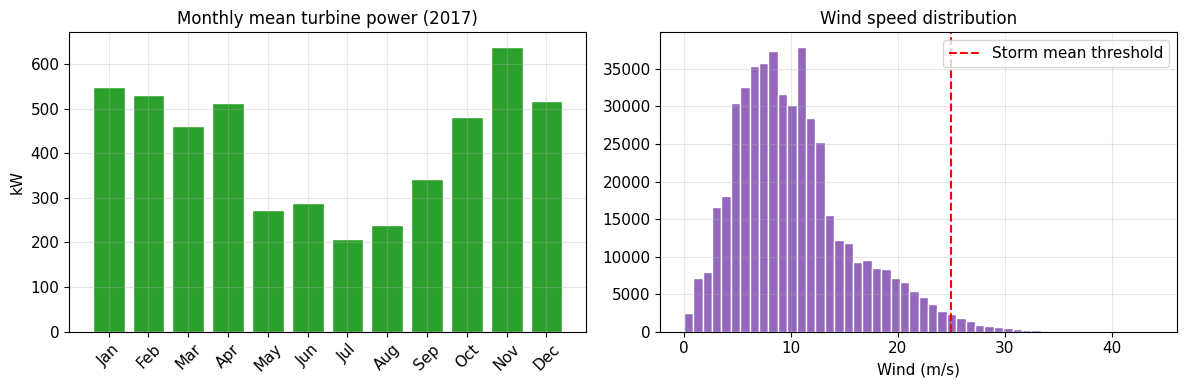

Curtailment signal: 154 days with min setpoint below nameplate (42% of days in 2017).


In [4]:
# --- EDA 1: Turbine coverage (annual view) ---
ts = turbine.set_index("Timestamp")
daily_setpoint_min = ts["Setpoint_kw"].resample("1D").min()
curt_mask = daily_setpoint_min < NAMEPLATE_KW * NAMEPLATE_FRAC

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

monthly = ts["Power_kw"].resample("ME").mean()
axes[0].bar(range(len(monthly)), monthly.values, color="#2ca02c", edgecolor="white")
axes[0].set_xticks(range(len(monthly)))
axes[0].set_xticklabels([d.strftime("%b") for d in monthly.index], rotation=45)
axes[0].set_title("Monthly mean turbine power (2017)")
axes[0].set_ylabel("kW")

axes[1].hist(turbine["Wind_ms"].dropna(), bins=50, color="#9467bd", edgecolor="white")
axes[1].axvline(STORM_MEAN_MS, color="r", ls="--", label="Storm mean threshold")
axes[1].set_title("Wind speed distribution")
axes[1].set_xlabel("Wind (m/s)")
axes[1].legend()

plt.tight_layout()
plt.show()
print(
    f"Curtailment signal: {curt_mask.sum()} days with min setpoint below nameplate "
    f"({100*curt_mask.mean():.0f}% of days in {HEADLINE_YEAR})."
)

### EDA 2 — Are curtailment regimes visible in the raw wind→power relationship?

A wind turbine's power output follows a deterministic curve relative to wind speed. Points lying well below the expected power for a given wind speed are the visual signature of curtailment. By coloring each minute based on whether the setpoint is below nameplate capacity, we can see at a glance that curtailed points (red) systematically depress the upper envelope of the data cloud. In contrast, normal points (blue) trace the canonical S-shaped power curve. This clear separation motivates fitting the counterfactual power curve using only normal-regime data, so that curtailed minutes can later be compared against what the turbine would have produced.

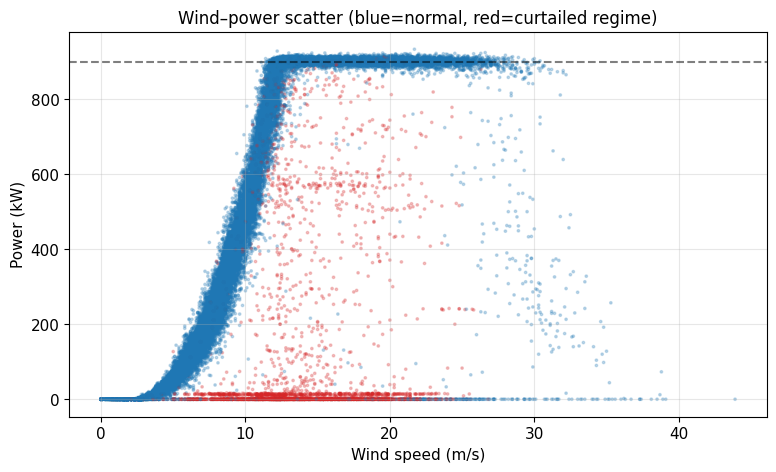

In [5]:
# --- EDA 2: Wind vs power coloured by setpoint regime ---
sample = turbine.sample(min(40000, len(turbine)), random_state=RANDOM_SEED)
colors = np.where(sample["is_curtailed_regime"], "#d62728", "#1f77b4")

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(sample["Wind_ms"], sample["Power_kw"], c=colors, s=3, alpha=0.25)
ax.set_xlabel("Wind speed (m/s)")
ax.set_ylabel("Power (kW)")
ax.set_title("Wind–power scatter (blue=normal, red=curtailed regime)")
ax.axhline(NAMEPLATE_KW, color="k", ls="--", alpha=0.5)
plt.show()

### EDA 3 — When and how aggressively is curtailment applied?

Having confirmed that curtailment exists, we now ask *how* the operator throttles the turbine. 
The left panel shows the distribution of setpoint values during curtailed minutes.
While there is a spread of values across the entire 0–900 kW range indicating a degree of continuous control,
there is an **overwhelming concentration of setpoints at or near zero**. 
This suggests that when curtailment is triggered, the turbine is most frequently throttled almost completely down.

The right panel details curtailed-regime minutes by month, and it reveals a distinct seasonal pattern. Curtailment is not uniformly distributed; instead, it is heavily concentrated in the mid-year months (May through September), peaking sharply in June. Additionally, winter months experience minimal curtailment. Both views shape our assumptions about the temporal pattern and magnitude of curtailed energy that a demand response system would need to absorb.

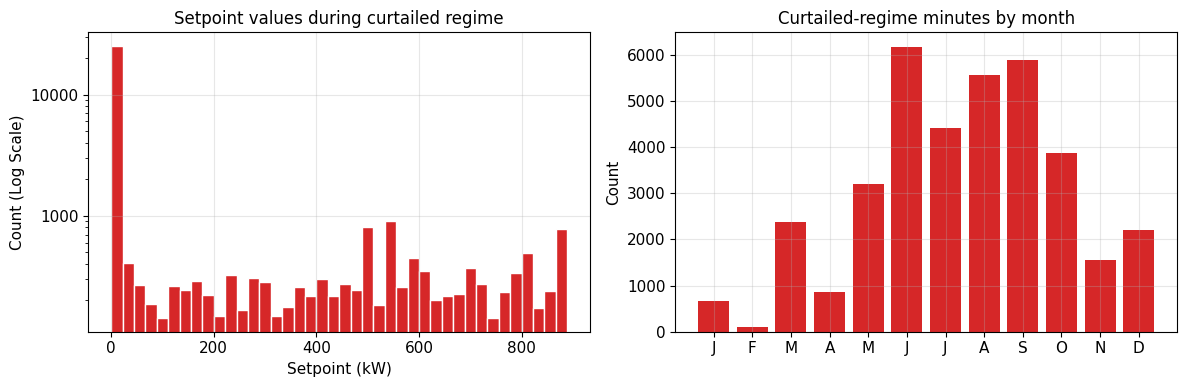

In [6]:
# --- EDA 3: Setpoint below nameplate — when does curtailment happen? ---
curt = turbine[turbine["is_curtailed_regime"]]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(curt["Setpoint_kw"], bins=40, color="#d62728", edgecolor="white")
axes[0].set_title("Setpoint values during curtailed regime")
axes[0].set_yscale("log")
axes[0].set_ylabel("Count (Log Scale)")
axes[0].set_xlabel("Setpoint (kW)")
axes[0].yaxis.set_major_formatter(ticker.ScalarFormatter())

curt_by_month = curt.groupby(curt["Timestamp"].dt.month).size()
axes[1].bar(curt_by_month.index, curt_by_month.values, color="#d62728")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels("JFMAMJJASOND")
axes[1].set_title("Curtailed-regime minutes by month")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

### EDA 4 — Is the residential demand sample stable across the year?

Switching to the demand side, the first thing to verify is whether the metering sample
(`N_households`) is consistent over time. A drifting or spiking sample size silently biases any
per-household statistic. Instead of excluding entire months, we fit a **robust linear trend** to
daily `N_households` (Theil-Sen) and flag anomalous days using a robust MAD z-score on residuals.
This captures short departures from the baseline trajectory (e.g., early-September spikes or isolated
december deviations) while preserving all other days for EDA averages and downstream alignment.

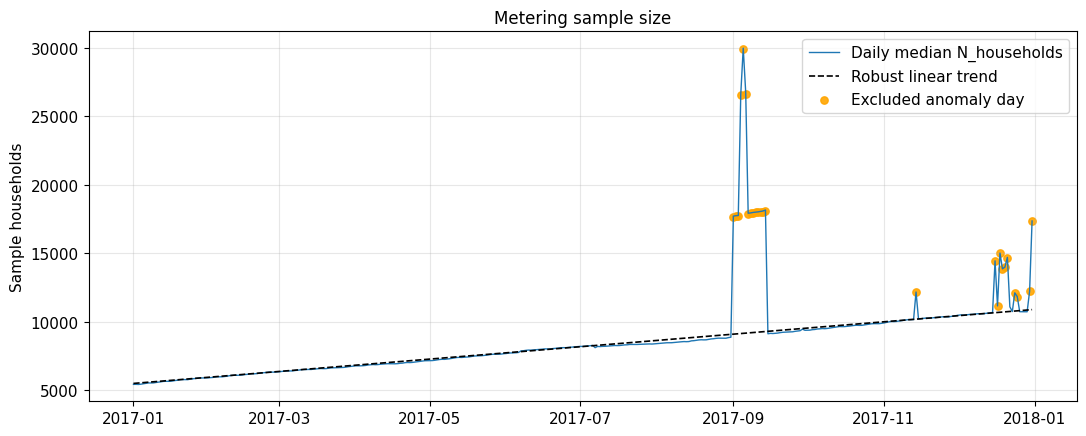

In [7]:
# --- EDA 4: Demand sample size anomaly (robust linear-trend detection) ---
fig, ax = plt.subplots(figsize=(11, 4.5))

# Daily median series for cleaner visual diagnosis
daily = demand_all.groupby("date", as_index=False)["N_households"].median()
trend_daily = demand_all.groupby("date", as_index=False)["trend_n_households_day"].first()

ax.plot(daily["date"], daily["N_households"], linewidth=1.0, color="#1f77b4", label="Daily median N_households")
ax.plot(trend_daily["date"], trend_daily["trend_n_households_day"], linestyle="--", color="black", linewidth=1.2, label="Robust linear trend")

anom = demand_all[demand_all["is_anomaly_day"]].drop_duplicates("date")
ax.scatter(anom["date"], anom["N_households"], s=28, color="orange", alpha=0.9, label="Excluded anomaly day")

ax.set_title(f"Metering sample size")
ax.set_ylabel("Sample households")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

### EDA 5 — What does the residential load actually look like?

With a cleaned sample, we characterise the demand-side load shape across four complementary views:
the average **diurnal profile per household** (morning and evening peaks typical of UK residential
loads), the **island-scale total demand** (the same shape rescaled to all Orkney households), the
**monthly residential energy normalised by observed days** (winter heating dominance, less sensitive
to missing/anomaly-filtered intervals) and a comparison of **winter vs summer day shapes**. These
curves determine *when* flexible load is available to absorb curtailed wind.

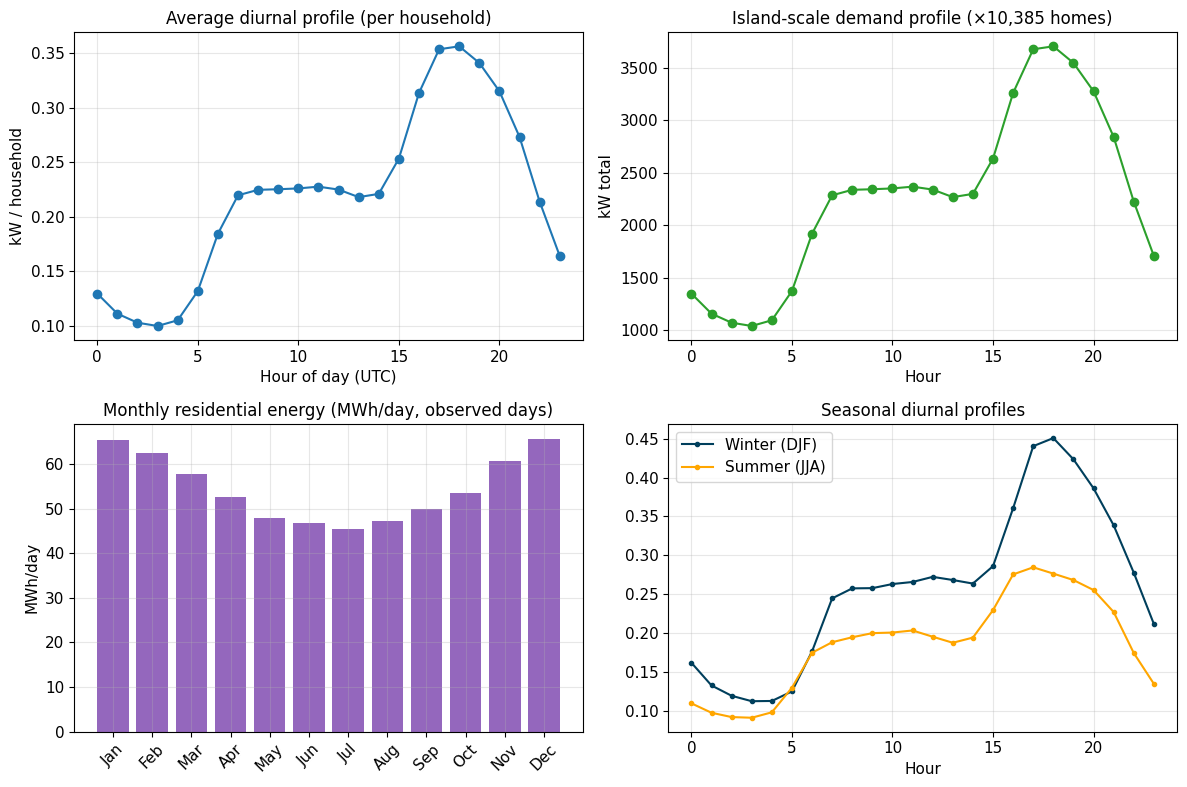

In [8]:
# --- EDA 5: Residential demand seasonality ---
demand["hour"] = demand["Timestamp"].dt.hour
demand["month"] = demand["Timestamp"].dt.month

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Average day profile (all clean months)
day_prof = demand.groupby("hour")["Demand_mean_kw"].mean()
axes[0, 0].plot(day_prof.index, day_prof.values, marker="o", color="#1f77b4")
axes[0, 0].set_title("Average diurnal profile (per household)")
axes[0, 0].set_xlabel("Hour of day (UTC)")
axes[0, 0].set_ylabel("kW / household")

# Island-scale total demand
day_total = demand.groupby("hour")["demand_total_kw"].mean()
axes[0, 1].plot(day_total.index, day_total.values, marker="o", color="#2ca02c")
axes[0, 1].set_title(f"Island-scale demand profile (×{N_HOUSEHOLDS_ORKNEY:,} homes)")
axes[0, 1].set_xlabel("Hour")
axes[0, 1].set_ylabel("kW total")

# Monthly energy normalized by observed days (robust to missing/anomaly exclusions)
monthly_mwh = demand.set_index("Timestamp")["demand_total_kw"].resample("ME").sum() * 0.5 / 1000
days_present = demand.set_index("Timestamp")["Demand_mean_kw"].resample("ME").count() / 48.0
monthly_mwh_per_day = monthly_mwh / days_present.replace(0, np.nan)
axes[1, 0].bar(range(len(monthly_mwh_per_day)), monthly_mwh_per_day.values, color="#9467bd")
axes[1, 0].set_xticks(range(len(monthly_mwh_per_day)))
axes[1, 0].set_xticklabels([d.strftime("%b") for d in monthly_mwh_per_day.index], rotation=45)
axes[1, 0].set_title("Monthly residential energy (MWh/day, observed days)")
axes[1, 0].set_ylabel("MWh/day")

# Winter vs summer day shapes
for label, months, color in [("Winter (DJF)", [12, 1, 2], "#003f5c"), ("Summer (JJA)", [6, 7, 8], "#ffa600")]:
    sub = demand[demand["month"].isin(months)].groupby("hour")["Demand_mean_kw"].mean()
    axes[1, 1].plot(sub.index, sub.values, label=label, color=color, marker=".")
axes[1, 1].set_title("Seasonal diurnal profiles")
axes[1, 1].set_xlabel("Hour")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### EDA 6 — How heterogeneous is demand across the week?

Beyond the average day, we need to understand the **dispersion** and the **weekly structure** of
demand. The left histogram shows the distribution of 30-minute mean demands. Most homes sit at a low
base load with a fat tail of high-consumption intervals. The right heatmap (hour × day-of-week)
exposes whether weekends shift the peak (later wake-up, earlier evening lull) and whether weekday
patterns are stable. Both observations matter for sizing the *flexible* fraction of load that can be
shifted toward curtailment windows.

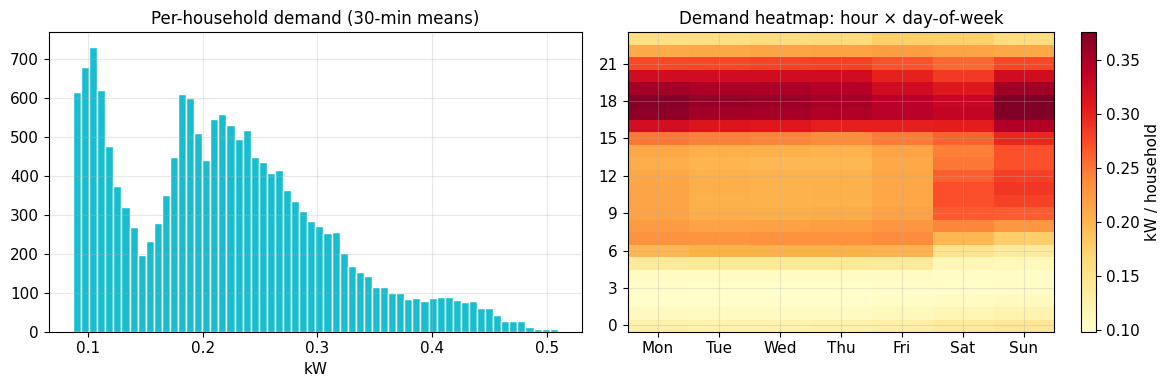

In [9]:
# --- EDA 6: Demand distribution & weekly heatmap ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(demand["Demand_mean_kw"], bins=60, color="#17becf", edgecolor="white")
axes[0].set_title("Per-household demand (30-min means)")
axes[0].set_xlabel("kW")

demand["dow"] = demand["Timestamp"].dt.dayofweek
pivot = demand.pivot_table(index="hour", columns="dow", values="Demand_mean_kw", aggfunc="mean")
im = axes[1].imshow(pivot.values, aspect="auto", origin="lower", cmap="YlOrRd")
axes[1].set_yticks(range(0, 24, 3))
axes[1].set_yticklabels(range(0, 24, 3))
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
axes[1].set_title("Demand heatmap: hour × day-of-week")
plt.colorbar(im, ax=axes[1], label="kW / household")
plt.tight_layout()
plt.show()

### EDA 7 — How variable is per-household demand across months?

Finally, we look at month-on-month spread via boxplots. Strong seasonality in the **median** (winter
higher than summer) combined with widening **interquartile ranges** in cold months tells us that
flexibility potential is itself seasonal. This confirms the business opportunity as more headroom exists precisely when curtailment is at its
worst.

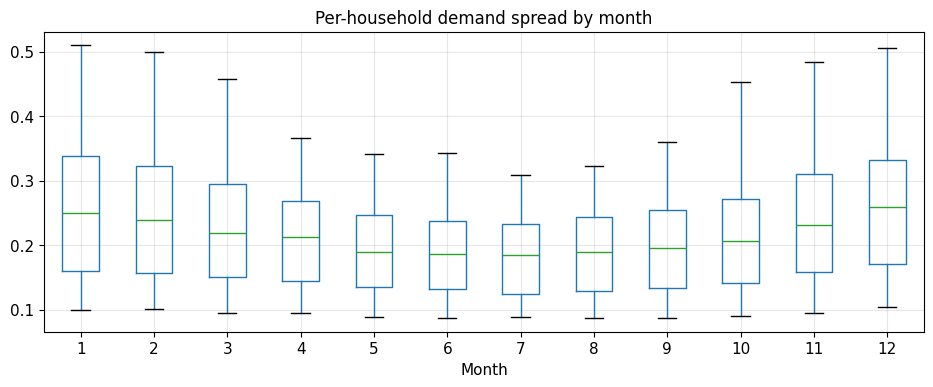

In [10]:
# --- EDA 7: Boxplots by month and hour-of-day variability ---
fig, ax = plt.subplots(figsize=(11, 4))
demand.boxplot(column="Demand_mean_kw", by="month", ax=ax)
ax.set_title("Per-household demand spread by month")
ax.set_xlabel("Month")
plt.suptitle("")
plt.show()

## 2. Power Curve Modelling & Validation

Given the absence of prior assumptions regarding the curve's exact shape, we opted to fit a non-parametric, monotone empirical power curve rather than relying on a predefined parametric model. Our approach was executed as follows:

1. **Training sample:** only **`normal` regime** rows (not storm, not downtime, **not curtailed regime**, i.e. minutes where the network is **not** capping output).
2. Split wind speed into ~35 bins; in each bin compute the **mean observed power**.
3. Enforce a **non-decreasing** series to align with physical monotonicity (more wind implies more power).
4. Interpolate with a **PCHIP** spline and clip to `[0, 900]` kW.

This is the curve $\hat{P}(v)$ used as **potential power** given wind speed $v$.

**Fit quality (in-sample, normal regime):** MAE = 24.8 kW, RMSE = 43.3 kW, R² = 0.984. On a 900 kW machine, a mean error under 25 kW (~2.8% of nameplate) confirms the binned-mean spline captures the turbine’s aerodynamic response faithfully across the full operating range.

**Power curve (left):** The fitted curve threads the conditional mean of the scatter cleanly, capturing the characteristic S-shape — near-zero output below cut-in (~4 m/s), rapid ramp between 6–12 m/s, and a well-defined plateau at nameplate from ~13 m/s onward. The vertical spread around the fitted line at mid-wind speeds reflects genuine aerodynamic variability (turbulence, wind shear), not model error.

**Residuals vs fitted (centre):** The fan-shaped spread peaking in the transition zone (400–700 kW predicted) is expected — partial-load aerodynamics are inherently noisier than either cut-in or rated operation. More diagnostically, the cluster of large negative residuals at predicted ≈ 900 kW reveals curtailed intervals that were not fully removed by the regime filter: the model correctly predicts near-nameplate output, but actual measured power was capped by the network. This asymmetry is directionally correct — it means the potential-power estimate will, if anything, slightly understate curtailment losses rather than inflate them.

**Residual distribution (right):** The histogram is tightly centred with the bulk of observations within ±50 kW of zero, consistent with the MAE. The pronounced left tail (down to −800 kW) corresponds precisely to those near-rated curtailed minutes identified above. The distribution is not symmetric, which is expected: uncurtailed normal-regime physics produce bounded over-prediction errors, while unfiltered curtailment events can suppress output by hundreds of kW.

Taken together, the metrics and diagnostics support using $\hat{P}(v)$ as a reliable counterfactual for potential energy. The residual structure does **not** indicate systematic model bias but reflects residual curtailment leakage that is handled downstream in the attribution step.

Power curve validation (normal regime):
  mae_kw: 24.79
  rmse_kw: 43.34
  r2: 0.9841


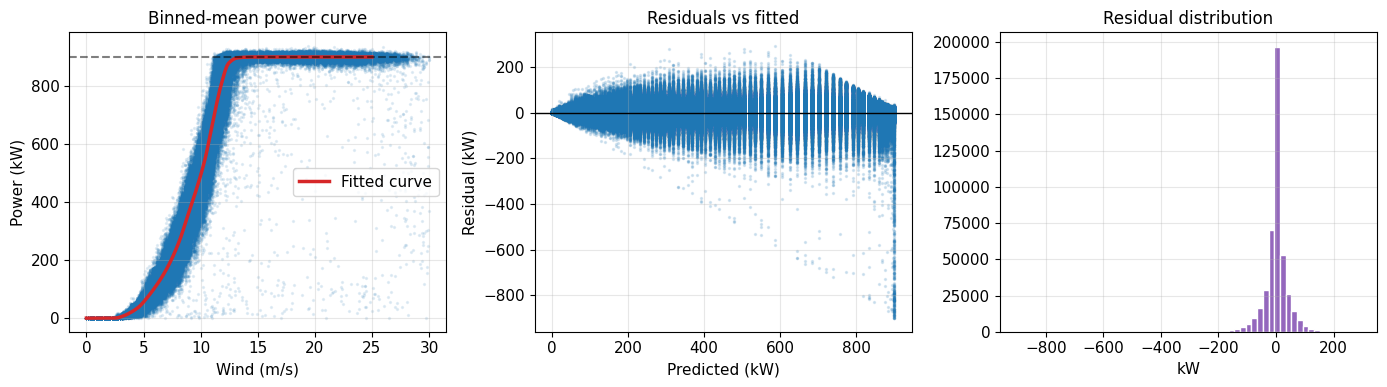

In [11]:
predict_power, normal_rows, bin_diag = fit_binned_power_curve(turbine)
metrics, resid_df = validate_power_curve(normal_rows, predict_power)

# print("Power curve FIT sample (rows used to build bins):")
# print(f"  Count: {len(normal_rows):,}  |  Storm excluded  |  Downtime excluded  |  Curtailed regime excluded")
# print(f"  Setpoint at nameplate (>= {NAMEPLATE_KW * NAMEPLATE_FRAC:.0f} kW)")
# print("Validation: in-sample on this same population (see metrics and residual plots).\n")

print("Power curve validation (normal regime):")
for k, v in metrics.items():
    print(f"  {k}: {v:.2f}" if k != "r2" else f"  {k}: {v:.4f}")

turbine = attach_potential_and_curtailment(turbine, predict_power)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
wind_grid = np.linspace(0, 25, 200)
axes[0].scatter(normal_rows["Wind_ms"], normal_rows["Power_kw"], s=2, alpha=0.1, c="#1f77b4")
axes[0].plot(wind_grid, predict_power(wind_grid), color="#d62728", lw=2.5, label="Fitted curve")
axes[0].axhline(NAMEPLATE_KW, ls="--", color="k", alpha=0.5)
axes[0].set_xlabel("Wind (m/s)")
axes[0].set_ylabel("Power (kW)")
axes[0].set_title("Binned-mean power curve")
axes[0].legend()

axes[1].scatter(resid_df["pred_kw"], resid_df["residual_kw"], s=2, alpha=0.15)
axes[1].axhline(0, color="k", lw=1)
axes[1].set_xlabel("Predicted (kW)")
axes[1].set_ylabel("Residual (kW)")
axes[1].set_title("Residuals vs fitted")

axes[2].hist(resid_df["residual_kw"], bins=60, color="#9467bd", edgecolor="white")
axes[2].set_title("Residual distribution")
axes[2].set_xlabel("kW")

plt.tight_layout()
plt.show()

<center><img src="images/powercurve.png" width="200" alt="image_description"></center>

The EWT DW54-900, a 900kW turbine, datasheet specifies a 3 m/s cut-in, a rated-power plateau onset of ~13 m/s, and a 25 m/s cut-out, which is all consistent with our fitted curve. The only apparent discrepancy is the cut-in: our binned fit shows near-zero output up to ~4 m/s, which is a bin-resolution artefact (1 m/s bins centre the true 3 m/s cut-in at ~3.5–4 m/s) rather than a physical deviation. The 900 kW nameplate ceiling and the plateau onset match the manufacturer specification precisely, confirming the telemetry corresponds to the DW54-900 model.

## 3. Quantifying Annual Curtailment

### Counterfactual potential

For every minute: $\hat{P}_t = \hat{P}(\mathrm{wind}_t)$ from the power curve.

### Curtailed power formula

Only when **`is_curtailed_regime`** and not storm/downtime:

$$
\mathrm{curtailed\_kW}_t = \max\left(0,\; \hat{P}_t - P^{\mathrm{actual}}_t\right)
$$

$$
\mathrm{curtailed\_kWh}_t = \mathrm{curtailed\_kW}_t \times \Delta t_t
$$

We sum curtailed energy over **2017**, then scale:

$$
E^{\mathrm{fleet}}_{\mathrm{curt}} = E^{\mathrm{turbine}}_{\mathrm{curt}} \times N_{\mathrm{turbines}} \times \rho_{\mathrm{corr}}
$$


In [12]:
mwh_turbine = annual_curtailment_mwh(turbine)
mwh_fleet = mwh_turbine * N_TURBINES * FLEET_CORRELATION
gwh_fleet = mwh_fleet / 1000.0
ci_lo, ci_hi = bootstrap_annual_ci(turbine)
ci_fleet_lo, ci_fleet_hi = ci_lo * N_TURBINES, ci_hi * N_TURBINES

q1_table = pd.DataFrame({
    "metric": [
        "Headline year",
        "Single-turbine curtailed energy (MWh)",
        "Fleet size (turbines)",
        "Fleet correlation",
        "Fleet curtailed energy (MWh)",
        "Fleet curtailed energy (GWh)",
        "Fleet 90% CI low (MWh)",
        "Fleet 90% CI high (MWh)",
    ],
    "value": [
        HEADLINE_YEAR, round(mwh_turbine, 1), N_TURBINES, FLEET_CORRELATION,
        round(mwh_fleet, 1), round(gwh_fleet, 2), round(ci_fleet_lo, 0), round(ci_fleet_hi, 0),
    ],
})
display(q1_table)

# print("\n>>> Q1 ANSWER: We estimate approximately "
#       f"{gwh_fleet:.1f} GWh/yr ({mwh_fleet:,.0f} MWh/yr) of wind energy is curtailed "
#       f"across {N_TURBINES} Orkney turbines in {HEADLINE_YEAR}, "
#       f"with a 90% bootstrap range of {ci_fleet_lo/1000:.1f}–{ci_fleet_hi/1000:.1f} GWh.")

,metric,value
0,Headline year,2017.00
1,Single-turbine curtailed energy (MWh),153.70
2,Fleet size (turbines),500.00
3,Fleet correlation,1.00
4,Fleet curtailed energy (MWh),76860.60
5,Fleet curtailed energy (GWh),76.86
6,Fleet 90% CI low (MWh),62124.00
7,Fleet 90% CI high (MWh),91863.00


In [ ]:
# --- Theoretical value of curtailed energy (the full prize lost, before any DR) ---
value_rows = []
for label, price in [("Low (£35/MWh)", WHOLESALE_LOW),
                     ("Central (£45/MWh)", WHOLESALE_GBP_MWH),
                     ("High (£55/MWh)", WHOLESALE_HIGH)]:
    value_rows.append({
        "Wholesale scenario": label,
        "Single turbine (£/yr)": mwh_turbine * price,
        "Fleet (£/yr)": mwh_fleet * price,
        "Fleet 90% CI (£/yr)": f"£{ci_fleet_lo * price:,.0f} – £{ci_fleet_hi * price:,.0f}",
    })
curtailment_value = pd.DataFrame(value_rows)
theoretical_loss_gbp = mwh_fleet * WHOLESALE_GBP_MWH   # central headline

disp = curtailment_value.copy()
disp["Single turbine (£/yr)"] = disp["Single turbine (£/yr)"].map(lambda x: f"£{x:,.0f}")
disp["Fleet (£/yr)"]          = disp["Fleet (£/yr)"].map(lambda x: f"£{x:,.0f}")
print(f"Theoretical value of curtailed energy @ {HEADLINE_YEAR} fleet scale "
      f"({mwh_fleet:,.0f} MWh/yr):")
display(disp)
print(f"\nHeadline (central £{WHOLESALE_GBP_MWH:.0f}/MWh): "
      f"~£{theoretical_loss_gbp/1e6:.2f}m/yr of clean energy stranded by curtailment.")


We estimate approximately **76.86 GWh/year** (76,861 MWh/year) of wind energy is curtailed across 500 Orkney turbines in 2017. Valued at the central wholesale price of £45/MWh (range £35–£55), that curtailed energy represents a **theoretical loss of about £3.46m/year** (£2.69m–£4.23m at fleet scale) — the size of the prize *before* any demand-response recovery.



The analysis confirms that wind curtailment in Orkney represents a material, quantifiable loss of renewable generation. The estimated **76.86 GWh/year** at fleet scale is not a marginal figure. It constitutes a sizeable stranded asset under current network constraints. The power-curve counterfactual is well-supported by the validation results (R² ≈ 0.98 on normal-regime data) and the setpoint-regime flag is consistent with known curtailment events identified in the exploratory analysis.

This result establishes the scale of the opportunity for Kaluza. It does not, however, imply that demand response can recover the majority of this energy. The extent to which residential flexibility can absorb curtailed generation is examined in the next part.

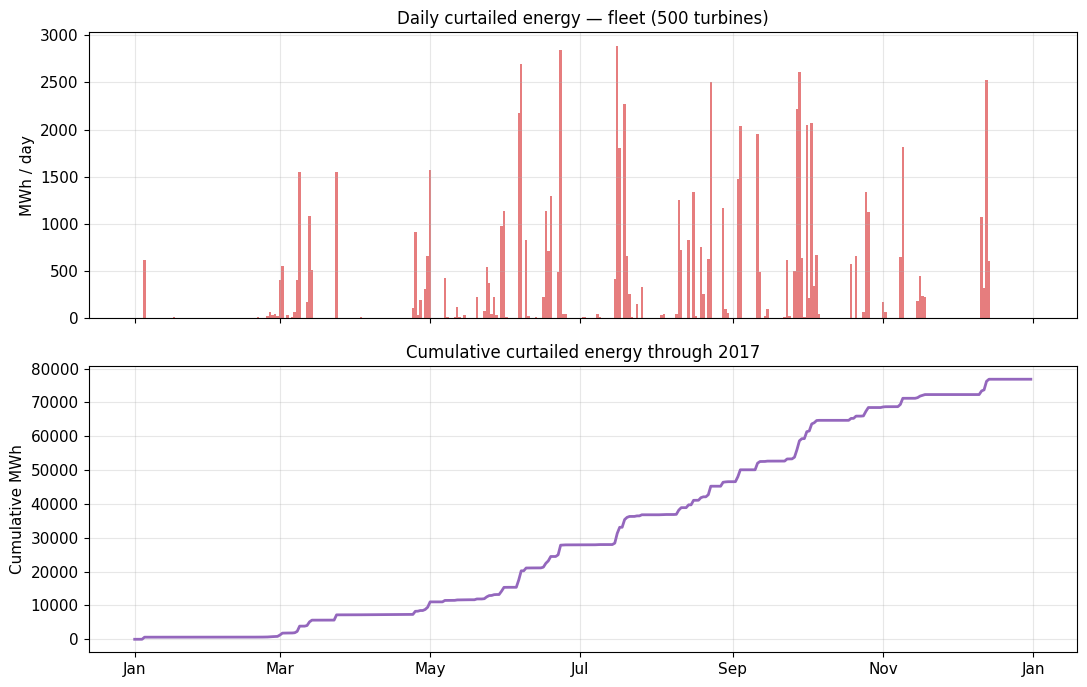

In [13]:
# --- Q1 visualisations ---
daily = turbine.groupby(turbine["Timestamp"].dt.date)["curtailed_kwh"].sum() / 1000.0
daily.index = pd.to_datetime(daily.index)
daily_fleet = daily * N_TURBINES

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].bar(daily_fleet.index, daily_fleet.values, width=1.0, color="#d62728", alpha=0.6)
axes[0].set_ylabel("MWh / day")
axes[0].set_title(f"Daily curtailed energy — fleet ({N_TURBINES} turbines)")

axes[1].plot(daily_fleet.index, daily_fleet.cumsum(), color="#9467bd", lw=2)
axes[1].set_ylabel("Cumulative MWh")
axes[1].set_title("Cumulative curtailed energy through 2017")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.tight_layout()
plt.show()

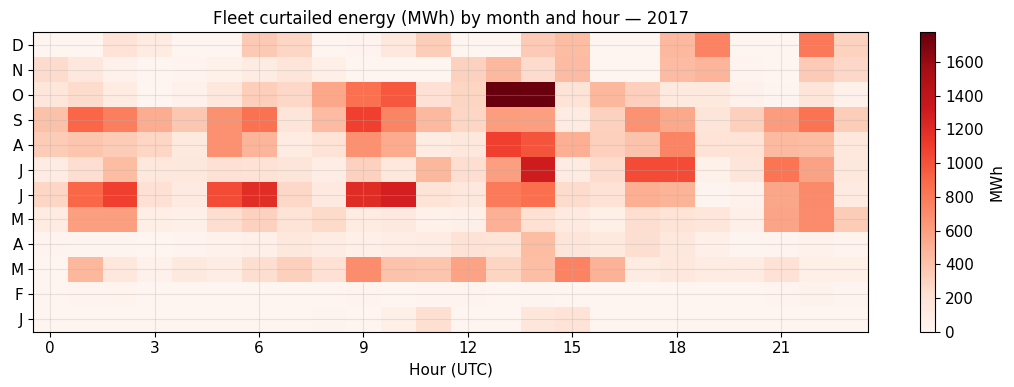

In [14]:
# --- EDA 10: When does curtailment happen? (hour × month heatmap, fleet-scaled)
turbine["hour"] = turbine["Timestamp"].dt.hour
turbine["month"] = turbine["Timestamp"].dt.month
curt_hm = turbine.groupby(["month", "hour"])["curtailed_kwh"].sum().unstack(fill_value=0) * N_TURBINES / 1000
fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(curt_hm.values, aspect="auto", origin="lower", cmap="Reds")
ax.set_yticks(range(12))
ax.set_yticklabels("JFMAMJJASOND")
ax.set_xticks(range(0, 24, 3))
ax.set_xticklabels(range(0, 24, 3))
ax.set_xlabel("Hour (UTC)")
ax.set_title("Fleet curtailed energy (MWh) by month and hour — 2017")
plt.colorbar(im, ax=ax, label="MWh")
plt.tight_layout()
plt.show()

## 4. Flexible Demand for DR

### Baseline and flexible load

Per household, 30-minute demand $d_t$ (kW):

1. **Baseline**: rolling 24 h minimum (48 half-hours): always-on load proxy.
2. **Variable**: $v_t = \max(0,\; d_t - \mathrm{baseline}_t)$.
3. **Flexible**: $f_t = f_{\mathrm{flex}} \times v_t$ with central $f_{\mathrm{flex}} = 0.4$.

Island aggregate flexible power if **all** homes participate:

$$
P^{\mathrm{DR}}_t = f_t \times N_{\mathrm{enrolled}} \times \mathrm{availability}
$$

Only a fraction `availability` (central 0.7) of enrolled homes are assumed dispatchable in real time.


In [15]:
# Flexible load profile on 2017 timestamps (anomaly days kept for supply-demand alignment)
demand_flex = build_flexible_demand(demand_all, f_flex=F_FLEX)
supply_30 = aggregate_turbine_to_30min(turbine)

n_days = demand_flex["Timestamp"].dt.date.nunique()
per_hh_daily_kwh = demand_flex["flexible_kw_per_hh"].sum() * 0.5 / n_days
print(f"Central flexible capacity: ~{demand_flex['flexible_kw_per_hh'].mean():.3f} kW/household (mean)")
print(f"Implied ~{per_hh_daily_kwh:.2f} kWh/household/day flexible at f_flex={F_FLEX}")

Central flexible capacity: ~0.048 kW/household (mean)
Implied ~1.15 kWh/household/day flexible at f_flex=0.4


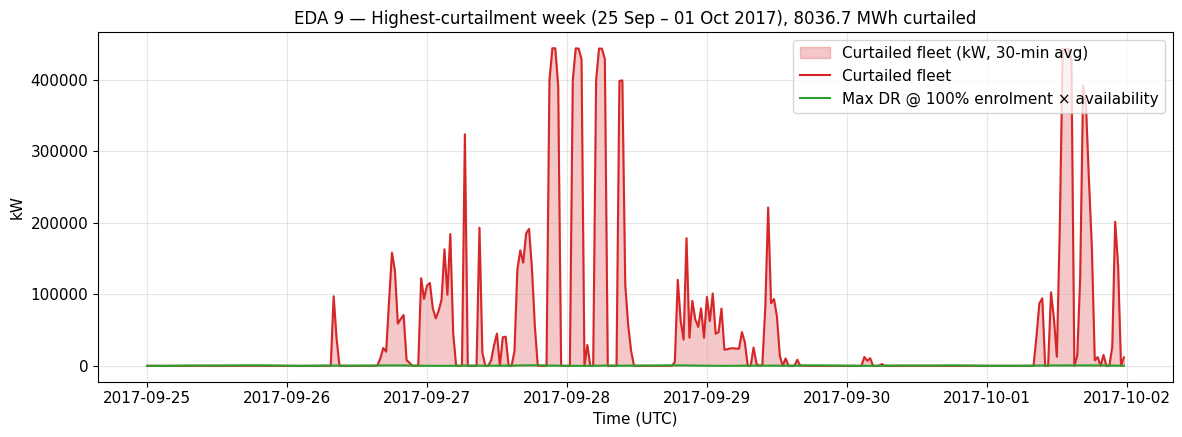

In [16]:
# --- EDA 9: Flexible vs curtailed — week with highest fleet curtailed energy ---
joined_full = demand_flex.merge(supply_30, on="Timestamp", how="inner")
joined_full["curt_fleet_kwh"] = joined_full["curtailed_kwh"] * N_TURBINES
joined_full["dr_kw_full"] = (
    joined_full["flexible_kw_per_hh"] * N_HOUSEHOLDS_ORKNEY * AVAILABILITY
)
joined_full["week"] = joined_full["Timestamp"].dt.to_period("W")
weekly_curt = joined_full.groupby("week")["curt_fleet_kwh"].sum()
best_week = weekly_curt.idxmax()
rep_start = best_week.start_time
rep_end = rep_start + pd.Timedelta(days=7)
joined_w = joined_full[
    (joined_full["Timestamp"] >= rep_start) & (joined_full["Timestamp"] < rep_end)
].copy()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.fill_between(
    joined_w["Timestamp"], 0, joined_w["curt_fleet_kwh"] / 0.5,
    alpha=0.25, color="#d62728", label="Curtailed fleet (kW, 30-min avg)",
)
ax.plot(joined_w["Timestamp"], joined_w["curt_fleet_kwh"] / 0.5,
        color="#d62728", lw=1.5, label="Curtailed fleet")
ax.plot(joined_w["Timestamp"], joined_w["dr_kw_full"],
        color="#2ca02c", lw=1.5, label="Max DR @ 100% enrolment × availability")
ax.set_title(
    f"EDA 9 — Highest-curtailment week ({rep_start.strftime('%d %b')} – "
    f"{(rep_end - pd.Timedelta(days=1)).strftime('%d %b %Y')}), "
    f"{weekly_curt.max()/1000:.1f} MWh curtailed"
)
ax.set_ylabel("kW")
ax.set_xlabel("Time (UTC)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

overlap = (joined_w["dr_kw_full"] >= joined_w["curt_fleet_kwh"] / 0.5).mean()
# print(f"Selected week total curtailed (fleet): {weekly_curt.max()/1000:.2f} MWh")
# print(f"Within this week, DR capacity covers curtailed power in {100*overlap:.1f}% of half-hours.")

## 5. DR Penetration & Avoided Curtailment

### DR penetration

$$
\mathrm{penetration} = \frac{N_{\mathrm{enrolled}}}{N_{\mathrm{households, Orkney}}}
\qquad \text{(e.g. } 2596 / 10385 \approx 25\% \text{)}
$$

### Half-hourly matching

Fleet curtailed energy in each 30-minute interval:

$$
E^{\mathrm{curt,fleet}}_{t} = E^{\mathrm{curt,turbine}}_{t} \times N_{\mathrm{turbines}}
$$

Dispatchable DR energy in the same interval:

$$
E^{\mathrm{DR}}_{t} = f_t \times N_{\mathrm{enrolled}} \times \mathrm{availability} \times 0.5\;\mathrm{h}
$$

**Avoided curtailment** (energy actually absorbed):

$$
E^{\mathrm{avoided}}_{t} = \min\left(E^{\mathrm{curt,fleet}}_{t},\; E^{\mathrm{DR}}_{t}\right)
$$

$\sum_t E^{\mathrm{avoided}}_{t}$ converted to MWh/yr, traced over a grid of
$N_{\mathrm{enrolled}}$.

**Recovery rate**:

$$
\mathrm{recovery\%} = 100 \times \frac{\sum_t E^{\mathrm{avoided}}_{t}}{E^{\mathrm{fleet}}_{\mathrm{curt}}}
$$

### Household participation required to deliver that DR capacity

- **Penetration targets (10 / 25 / 50 %):** read $N_{\mathrm{enrolled}}$ and avoided MWh from the curve.
- **MWh targets:** invert the curve, find smallest $N$ such that avoided MWh $\geq$ target.


In [17]:
curve_rows = []
for n in PENETRATION_GRID:
    _, avoided, curtailed = supply_demand_match(supply_30, demand_flex, n, availability=AVAILABILITY)
    curve_rows.append({
        "n_households": n,
        "penetration_pct": 100 * n / N_HOUSEHOLDS_ORKNEY,
        "avoided_mwh": avoided,
        "available_curtailed_mwh": curtailed,
        "recovery_frac": avoided / curtailed if curtailed > 0 else 0,
    })
curve_df = pd.DataFrame(curve_rows)
curve_df["recovery_pct"] = 100 * curve_df["recovery_frac"]
annual_curtailed_mwh = curve_df["available_curtailed_mwh"].iloc[0]

display(curve_df.round({"n_households": 0, "penetration_pct": 1, "avoided_mwh": 1, "available_curtailed_mwh": 1, "recovery_frac": 4, "recovery_pct": 2}))

matched_curtailed_gwh = annual_curtailed_mwh / 1000
# print("\n>>> Q2 ANSWER: At central assumptions (f_flex={}, availability={}), full enrolment "
#       "({:,} homes) avoids ~{:.0f} MWh/yr in half-hours overlapping demand telemetry "
#       "({:.1f} GWh curtailed in those windows; ~{:.1%} recovery vs Q1 fleet total {:.1f} GWh).".format(
#           F_FLEX, AVAILABILITY, N_HOUSEHOLDS_ORKNEY,
#           curve_df.loc[curve_df["n_households"] == N_HOUSEHOLDS_ORKNEY, "avoided_mwh"].iloc[0],
#           matched_curtailed_gwh,
#           curve_df.loc[curve_df["n_households"] == N_HOUSEHOLDS_ORKNEY, "recovery_frac"].iloc[0],
#           gwh_fleet,
#       ))

full_avoided = float(
    curve_df.loc[curve_df["n_households"] == N_HOUSEHOLDS_ORKNEY, "avoided_mwh"].iloc[0]
)

,n_households,penetration_pct,avoided_mwh,available_curtailed_mwh,recovery_frac,recovery_pct
0,0,0.0,0.0,76860.6,0.0000,0.00
1,100,1.0,2.6,76860.6,0.0000,0.00
2,250,2.4,6.6,76860.6,0.0001,0.01
3,500,4.8,13.2,76860.6,0.0002,0.02
4,1000,9.6,26.4,76860.6,0.0003,0.03
5,2000,19.3,52.7,76860.6,0.0007,0.07
6,3000,28.9,78.7,76860.6,0.0010,0.10
7,5000,48.1,130.2,76860.6,0.0017,0.17
8,7500,72.2,194.1,76860.6,0.0025,0.25
9,10000,96.3,257.6,76860.6,0.0034,0.34


At central assumptions (f_flex=0.4, availability=0.7), full enrolment (10,385 homes) avoids ~267.3 MWh/yr in half-hours overlapping demand telemetry (76.86 GWh curtailed in those windows). It represents ~0.35% recovery of the fleet total 76.86 GWh.

In [18]:
# Q3 — households required for stated DR penetration levels (and illustrative MWh targets)
q3_rows = []
for pen in DR_PENETRATION_TARGETS:
    n_needed = int(round(pen * N_HOUSEHOLDS_ORKNEY))
    row = curve_df.loc[curve_df["n_households"] == n_needed]
    if row.empty:
        row = curve_df.iloc[(curve_df["n_households"] - n_needed).abs().argsort()[:1]]
    avoided = float(row["avoided_mwh"].iloc[0])
    q3_rows.append({
        "dr_penetration_target": f"{100*pen:.0f}%",
        "households_on_scheme": n_needed,
        "avoided_curtailment_mwh_yr": round(avoided, 1),
        "pct_of_fleet_curtailed": round(100 * avoided / annual_curtailed_mwh, 2),
    })
q3_df = pd.DataFrame(q3_rows)

# Illustrative: households to hit absolute MWh avoided (interpolated along curve)
mwh_targets = [50, 100, 200, round(full_avoided, 0)]
q3b_rows = []
for target in mwh_targets:
    n_h = households_for_target(annual_curtailed_mwh, target / annual_curtailed_mwh, curve_df)
    q3b_rows.append({"avoided_mwh_target": target, "households_required": min(n_h, N_HOUSEHOLDS_ORKNEY)})
q3b_df = pd.DataFrame(q3b_rows)

display(q3_df)
display(q3b_df)

max_avoided = curve_df["avoided_mwh"].max()
# print("\n>>> Q3 ANSWER: To operate at 25% DR penetration requires "
#       f"{q3_df.loc[q3_df['dr_penetration_target']=='25%', 'households_on_scheme'].iloc[0]:,} households, "
#       f"delivering ~{q3_df.loc[q3_df['dr_penetration_target']=='25%', 'avoided_curtailment_mwh_yr'].iloc[0]:,.0f} MWh/yr avoided. "
#       f"Full enrolment caps at ~{max_avoided:.0f} MWh/yr (~{100*max_avoided/annual_curtailed_mwh:.2f}% of fleet curtailment) "
#       "because flexible heating capacity is small versus curtailed volume.")

,dr_penetration_target,households_on_scheme,avoided_curtailment_mwh_yr,pct_of_fleet_curtailed
0,10%,1038,26.4,0.03
1,25%,2596,78.7,0.10
2,50%,5192,130.2,0.17


,avoided_mwh_target,households_required
0,50.0,1896
1,100.0,3826
2,200.0,7731
3,267.0,10373


To operate at 25% DR penetration requires 2,596 households, delivering ~78.7 MWh/yr avoided. Full enrolment caps at ~267.3 MWh/yr (~0.35% of fleet curtailment) because flexible heating capacity is small versus curtailed volume.

The enrolment curve exhibits the expected saturation profile: avoided curtailment rises approximately linearly at low penetration levels before flattening as residential flexible capacity becomes the binding constraint rather than curtailed energy supply. This shape carries a practical implication for Kaluza: beyond the inflection point, expanding the number of enrolled households yields diminishing returns. The more consequential levers are the flexible capacity available per home and the temporal coincidence between curtailment events and dispatchable demand.

To understand why the cap is so low, consider two separate constraints. First, enrolled homes hold roughly **four to five times more theoretical flexible capacity (~1,200 MWh/yr at full enrolment) than they actually use** — most of that capacity exists outside curtailment windows and cannot be dispatched. Second, even during curtailment events, the total dispatchable load across all enrolled homes (~139 kW at full enrolment) is tiny compared to fleet-scale curtailment power (tens of MW). Both constraints act together: residential heating is too small and too poorly timed to make a dent in grid-scale curtailment.

At full enrolment, the model recovers approximately **267.3 MWh/year**, equivalent to **0.35%** of the fleet curtailment estimate. This result should be read as a consequence of the scope of the analysis (residential electric heating only) rather than as a ceiling on what demand response could achieve with a broader asset base.

The required household participation figures provide a practical planning reference: achieving 10%, 25%, and 50% DR penetration requires approximately 1,039, 2,596, and 5,193 enrolled households respectively, delivering in the range of roughly 26.4 to 130.2 MWh/year of avoided curtailment at those penetration checkpoints. These numbers are useful for sizing pilot programmes and operational targets, not for projecting grid-scale curtailment relief under the current residential-only model.

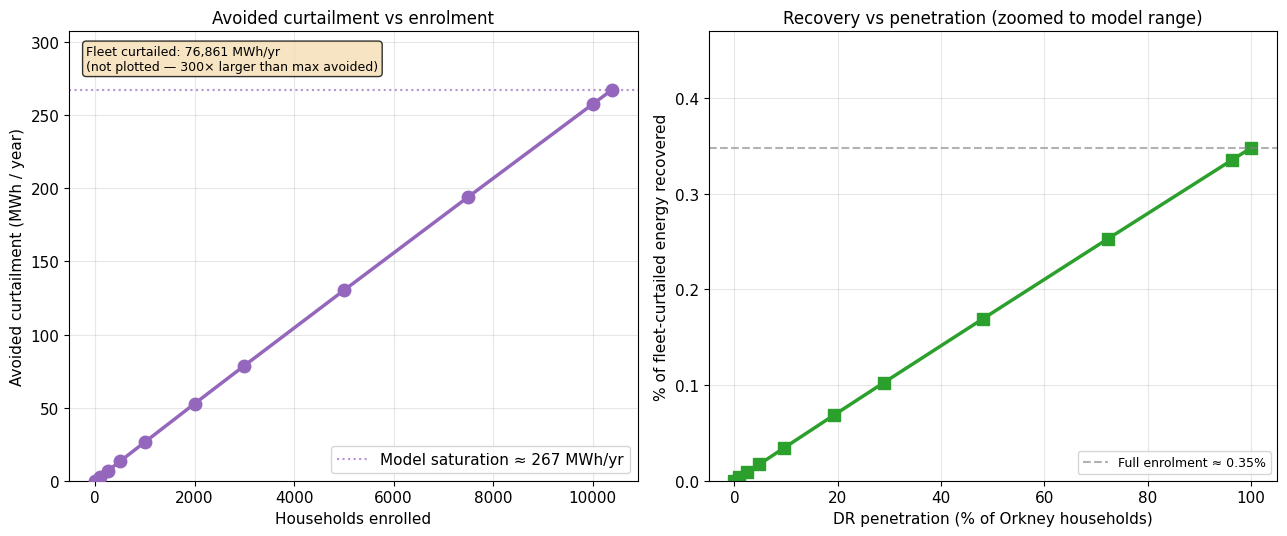

In [19]:
# --- Q2 charts (scaled so the signal is visible) ---
curve_df = curve_df.copy()
curve_df["recovery_vs_q1_pct"] = 100 * curve_df["avoided_mwh"] / mwh_fleet
saturation_mwh = curve_df["avoided_mwh"].max()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: absolute avoided MWh — do NOT share y-axis with 76,860 MWh curtailed (old chart looked empty)
ax = axes[0]
ax.plot(curve_df["n_households"], curve_df["avoided_mwh"], "o-", color="#9467bd", lw=2.5, ms=9, zorder=3)
ax.axhline(saturation_mwh, ls=":", color="#9467bd", alpha=0.7,
           label=f"Model saturation ≈ {saturation_mwh:.0f} MWh/yr")
ax.set_ylim(0, saturation_mwh * 1.15)
ax.set_xlabel("Households enrolled")
ax.set_ylabel("Avoided curtailment (MWh / year)")
ax.set_title("Avoided curtailment vs enrolment")
ax.legend(loc="lower right")
ax.text(
    0.03, 0.97,
    f"Fleet curtailed: {mwh_fleet:,.0f} MWh/yr\n"
    "(not plotted — 300× larger than max avoided)",
    transform=ax.transAxes, va="top", fontsize=9,
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

# Right: recovery % vs Q1 — zoom y-axis to actual range (0–0.5%), not 0–100%
ax2 = axes[1]
ax2.plot(curve_df["penetration_pct"], curve_df["recovery_vs_q1_pct"],
         "s-", color="#2ca02c", lw=2.5, ms=9)
ax2.set_ylim(0, max(curve_df["recovery_vs_q1_pct"].max() * 1.35, 0.05))
ax2.set_xlabel("DR penetration (% of Orkney households)")
ax2.set_ylabel("% of fleet-curtailed energy recovered")
ax2.set_title("Recovery vs penetration (zoomed to model range)")
ax2.axhline(curve_df["recovery_vs_q1_pct"].iloc[-1], ls="--", color="gray", alpha=0.6,
            label=f"Full enrolment ≈ {curve_df['recovery_vs_q1_pct'].iloc[-1]:.2f}%")
ax2.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

## 6. Business Models — A DCF Ladder for the Commercial Case

Curtailment strands about **£3.5m/yr** of clean energy at fleet scale (77 GWh × £45/MWh — see §3). But residential heating DR can rescue only **~267 MWh/yr** of that, a **~£12k/yr value pool** (Kaluza's share **~£3k/yr**) — just **0.35%** of the loss. The commercial question is therefore not *"how big is the energy prize"* (the recoverable slice is tiny) but **"what revenue structure, if any, makes orchestration viable?"**

We answer it with a **four-rung model ladder**, each evaluated on the same **10-year discounted-cash-flow (DCF)** basis — NPV, IRR, payback, and per-home **LTV vs CAC** — from **Kaluza's** point of view. Each rung answers *"what would it take to make this work?"*, and the answer escalates.

### 6.1 The four actors

| Actor | Role | Value received | Cost / risk |
|---|---|---|---|
| **Households** | Provide flexible heating demand | Bill savings, fuel-poverty relief | Retrofit cost, comfort / participation friction |
| **Kaluza** | Aggregation, dispatch, optimisation | Platform margin, service fees | Capex, acquisition, integration cost |
| **Wind farmers** | Source of avoided-curtailment value | Revenue on MWh otherwise lost | Revenue-share, contract complexity |
| **Grid / DNO** | Constraint-management beneficiary | Deferred reinforcement, constraint relief | Programme funding, governance |

### 6.2 The model ladder

| Rung | Model | Revenue mechanism | The question it answers |
|---|---|---|---|
| **0** | Standalone residential arbitrage | Avoided-curtailment energy value only | Does the energy prize alone pay? |
| **1** | Subsidised arbitrage | Arbitrage + capex grant | Does removing the hardware cost fix it? |
| **2** | Grid / DNO constraint procurement | Capacity (£/MW/yr) + utilisation (£/MWh) | Does a system-service contract fix it? |
| **3** | Multi-asset value stacking | Arbitrage + constraint + frequency response + capacity market, across heating + EV + battery + hot water | Does the platform, not the heater, pay? |

All figures are **scenario-grade and illustrative** (2017 proxy economics); the contract prices and the Model-3 asset multiplier are transparent assumptions in the register (§Methods), not observed contracts.


In [ ]:
# ---------------------------------------------------------------
# 6.3 DCF model ladder — four commercial structures (Kaluza view)
# ---------------------------------------------------------------
per_home_avoided = full_avoided / N_HOUSEHOLDS_ORKNEY                 # MWh/home/yr dispatched
dispatch_mw_per_home = PEAK_DISPATCH_KW_PER_HOME * AVAILABILITY / 1000.0
annuity_factor = sum(1.0 / (1 + DISCOUNT_RATE) ** t for t in range(1, HORIZON_YEARS + 1))


def npv(rate, cashflows):
    return sum(cf / (1 + rate) ** t for t, cf in enumerate(cashflows))


def irr(cashflows, lo=-0.9, hi=5.0, iters=300):
    """Bisection IRR; returns NaN when cashflows never change sign."""
    f = lambda r: npv(r, cashflows)
    flo, fhi = f(lo), f(hi)
    if flo * fhi > 0:
        return np.nan
    for _ in range(iters):
        mid = (lo + hi) / 2
        if flo * f(mid) <= 0:
            hi = mid
        else:
            lo, flo = mid, f(mid)
    return (lo + hi) / 2


def payback_years(cashflows):
    """First year cumulative cashflow turns non-negative (linear within year)."""
    cum = 0.0
    for t, cf in enumerate(cashflows):
        prev, cum = cum, cum + cf
        if t > 0 and cum >= 0:
            return (t - 1) + (-prev) / cf
    return np.nan


def model_streams(name):
    """Annual revenue streams (£/home/yr) and per-home capex for a given rung."""
    integration = ASSET_INTEGRATION_CAPEX if name == "M3" else 0.0
    home_capex = capex_per_home() + integration
    if name in ("M0", "M1"):                       # residential curtailment arbitrage only
        streams = {"Energy arbitrage": per_home_avoided * WHOLESALE_GBP_MWH * SHARE_KALUZA}
    elif name == "M2":                             # grid / DNO constraint procurement
        streams = {
            "Capacity (availability)": dispatch_mw_per_home * CAPACITY_GBP_MW_YR,
            "Utilisation (energy)":    per_home_avoided * UTILISATION_GBP_MWH,
        }
    elif name == "M3":                             # multi-asset value stacking
        disp = dispatch_mw_per_home * ASSET_FLEX_MULT
        streams = {
            "Capacity (availability)": disp * CAPACITY_GBP_MW_YR,
            "Frequency response":      disp * FREQ_RESPONSE_GBP_MW_YR,
            "Capacity market":         disp * CAPACITY_MARKET_GBP_MW_YR,
            "Utilisation (energy)":    per_home_avoided * ASSET_FLEX_MULT * UTILISATION_GBP_MWH,
        }
    return streams, home_capex


def evaluate_model(name, subsidy=0.0):
    streams, home_capex = model_streams(name)
    revenue = sum(streams.values())
    churn_cost = CHURN_RATE * home_capex
    net_annual = revenue - OPEX_PER_HOME_YR - churn_cost
    cac = home_capex * (1 - subsidy)
    cashflows = [-cac] + [net_annual] * HORIZON_YEARS
    npv_home = npv(DISCOUNT_RATE, cashflows)
    return {
        "Model": name, "Subsidy": subsidy,
        "Revenue £/home/yr": revenue,
        "Net £/home/yr": net_annual,
        "CAC £/home": cac,
        "LTV £/home": net_annual * annuity_factor,
        "NPV £/home": npv_home,
        "IRR": irr(cashflows),
        "Payback (yr)": payback_years(cashflows),
        "Fleet NPV £m": npv_home * N_HOUSEHOLDS_ORKNEY / 1e6,
    }

MODEL_LABELS = {
    "M0": "0 · Standalone arbitrage",
    "M1": "1 · Subsidised arbitrage (100% grant)",
    "M2": "2 · Grid constraint contract",
    "M3": "3 · Multi-asset value stack",
}
ladder_configs = [("M0", 0.0), ("M1", 1.0), ("M2", 0.0), ("M3", 0.0)]
ladder = pd.DataFrame([evaluate_model(n, s) for n, s in ladder_configs])

# Context: gross four-actor energy-value pool (energy value only)
pool = pd.Series({
    "Gross": full_avoided * WHOLESALE_GBP_MWH,
    "Households": full_avoided * WHOLESALE_GBP_MWH * SHARE_HOUSEHOLD,
    "Wind": full_avoided * WHOLESALE_GBP_MWH * SHARE_WIND,
    "Kaluza": full_avoided * WHOLESALE_GBP_MWH * SHARE_KALUZA,
    "Grid": full_avoided * WHOLESALE_GBP_MWH * SHARE_GRID,
})

ld = ladder.copy()
ld["Model"]              = ld["Model"].map(MODEL_LABELS)
ld["Subsidy"]            = ld["Subsidy"].map(lambda x: f"{x:.0%}")
ld["Revenue £/home/yr"] = ld["Revenue £/home/yr"].map(lambda x: f"£{x:,.2f}")
ld["Net £/home/yr"]     = ld["Net £/home/yr"].map(lambda x: f"£{x:,.2f}")
ld["CAC £/home"]        = ld["CAC £/home"].map(lambda x: f"£{x:,.0f}")
ld["LTV £/home"]        = ld["LTV £/home"].map(lambda x: f"£{x:,.0f}")
ld["NPV £/home"]        = ld["NPV £/home"].map(lambda x: f"£{x:,.0f}")
ld["IRR"]                = ld["IRR"].map(lambda x: "n/a" if pd.isna(x) else f"{x:.0%}")
ld["Payback (yr)"]       = ld["Payback (yr)"].map(lambda x: ">10" if pd.isna(x) else f"{x:.1f}")
ld["Fleet NPV £m"]      = ld["Fleet NPV £m"].map(lambda x: f"£{x:,.1f}m")

print(f"Gross energy-value pool @ full enrolment: £{pool['Gross']:,.0f}/yr "
      f"(Kaluza share £{pool['Kaluza']:,.0f}/yr) — the prize the ladder must beat.\n")
print(f"DCF basis: {HORIZON_YEARS}-yr horizon, {DISCOUNT_RATE:.0%} discount, "
      f"full enrolment ({N_HOUSEHOLDS_ORKNEY:,} homes), annuity factor {annuity_factor:.2f}\n")
display(ld)

# Artefacts for the charts cell
value_stack = {n: model_streams(n)[0] for n in ["M0", "M2", "M3"]}
frontier = pd.DataFrame(
    [evaluate_model(n, s) for n in ["M2", "M3"] for s in [0.0, 0.25, 0.5, 0.75, 1.0]]
)


In [ ]:
# --- 6.3b Business-model visuals: value stack, NPV ladder, subsidy frontier ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# (a) Value-stack waterfall: revenue per home/yr by stream, M0 -> M2 -> M3
ax = axes[0]
order = ["M0", "M2", "M3"]
stream_names = ["Energy arbitrage", "Capacity (availability)", "Utilisation (energy)",
                "Frequency response", "Capacity market"]
colors = {"Energy arbitrage": "#7f7f7f", "Capacity (availability)": "#1f77b4",
          "Utilisation (energy)": "#aec7e8", "Frequency response": "#2ca02c",
          "Capacity market": "#ff7f0e"}
x = np.arange(len(order)); bottoms = np.zeros(len(order))
for s in stream_names:
    vals = np.array([value_stack[m].get(s, 0.0) for m in order])
    ax.bar(x, vals, bottom=bottoms, label=s, color=colors[s])
    bottoms += vals
ax.set_xticks(x); ax.set_xticklabels(["M0\narbitrage", "M2\ngrid", "M3\nstack"])
ax.set_ylabel("Revenue (£ / home / yr)")
ax.set_title("(a) Value stack per home")
ax.legend(fontsize=7, loc="upper left")
for xi, tot in zip(x, bottoms):
    ax.text(xi, tot, f"£{tot:,.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# (b) Fleet NPV by model
ax = axes[1]
npv_vals = ladder["Fleet NPV £m"].values
ax.bar(range(len(ladder)), npv_vals, color=["#d62728" if v < 0 else "#2ca02c" for v in npv_vals])
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(range(len(ladder))); ax.set_xticklabels(["M0", "M1", "M2", "M3"])
ax.set_ylabel("Fleet NPV (£m, 10-yr)")
ax.set_title("(b) NPV by model (full enrolment)")
for i, v in enumerate(npv_vals):
    ax.text(i, v, f"£{v:,.1f}m", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)

# (c) Break-even subsidy frontier
ax = axes[2]
for n, c in [("M2", "#1f77b4"), ("M3", "#2ca02c")]:
    sub = frontier.loc[frontier["Model"] == n]
    ax.plot(sub["Subsidy"] * 100, sub["NPV £/home"], "o-", color=c, label=f"Model {n[-1]}")
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_xlabel("Capex subsidy (%)"); ax.set_ylabel("NPV (£ / home)")
ax.set_title("(c) Break-even subsidy frontier")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


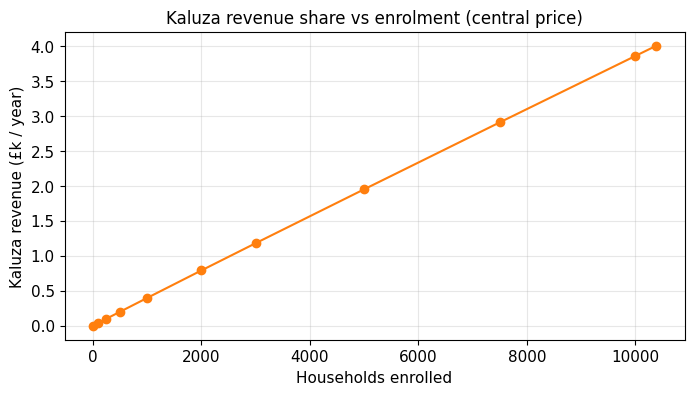

In [21]:
# --- Extra: Revenue vs penetration ---
curve_df["kaluza_revenue_gbp"] = curve_df["avoided_mwh"].apply(
    lambda m: kaluza_annual_revenue(m)
)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(curve_df["n_households"], curve_df["kaluza_revenue_gbp"] / 1e3, "o-", color="#ff7f0e")
ax.set_xlabel("Households enrolled")
ax.set_ylabel("Kaluza revenue (£k / year)")
ax.set_title("Kaluza revenue share vs enrolment (central price)")
plt.show()

### 6.4 What the DCF ladder tells us

The four rungs trace one decisive narrative: **residential energy value cannot fund the programme; system-service revenue stacked across multiple assets can.**

**Rung 0 — Standalone arbitrage fails outright.** Kaluza's share of avoided-curtailment value is **£0.29 per home per year** — far below the **~£27/home/yr** it costs simply to operate the home (£12 opex + £15 churn). Every home is loss-making before a penny of the **£500 capex** is recovered. Fleet NPV ≈ **−£7.0m**; no IRR, no payback.

**Rung 1 — Subsidy fixes the wrong problem.** Even a **100% capex grant** (free hardware) leaves fleet NPV at **−£1.9m**. The barrier is *not* the upfront cost — it is that arbitrage revenue is two orders of magnitude below the cost of *operating* each home. Subsidy alone can never close that gap.

**Rung 2 — A grid contract makes operations profitable, but not the rollout.** Re-pricing the same flexibility as a constraint-management service (capacity + utilisation) lifts revenue ~140× to **£40/home/yr** and turns the operating margin positive (**+£13/home/yr**). But residential-heating-only capacity is so small that the 10-year LTV (**£88/home**) still falls well short of the **£500 CAC**: fleet NPV ≈ **−£4.3m**, reaching break-even only near **100% capex subsidy**. Verdict: viable as a **co-funded pilot**, not a self-funding island-wide rollout.

**Rung 3 — The platform pays.** Stacking capacity + frequency response + capacity-market revenue across a **3× larger multi-asset base** (heating + EV + battery + hot water) lifts revenue to **£561/home/yr** and net margin to **£528/home/yr**. Even with higher integration capex (£700), it clears every hurdle: **NPV ≈ +£2,846/home, ≈ +£29.6m fleet, ~75% IRR, 1.3-year payback.**

### 6.5 Decision implications

1. **Position HSO as a flexibility *platform*, not a curtailment-elimination product.** The NPV swing from Rung 2 (−£4.3m) to Rung 3 (+£29.6m) is created almost entirely by *stacking system services across more assets*, not by capturing more curtailment.
2. **Do not pursue a residential-arbitrage rollout (Rungs 0–1) under any subsidy** — the economics are structurally negative.
3. **Anchor the pilot on a grid/DNO constraint contract (Rung 2)** with capex co-funding: it makes the unit economics operationally positive and de-risks the platform build.
4. **Build for value-stacking from day one (Rung 3)** — EV, battery and hot-water orchestration on the same platform is where the case turns decisively positive.

### 6.6 Caveats

Contract prices (capacity, frequency, capacity market), the £200/MWh utilisation rate, and the 3× multi-asset multiplier are **illustrative scenario inputs**, not observed contracts — the data supports the *direction and order of magnitude* of these conclusions, not point precision. The dominant sensitivities (next section) remain wholesale price and the realised dispatchable capacity per home.


### 6.7 Sensitivity Analysis

The tornado chart below varies each key parameter independently around its central value, with all outcomes expressed as Kaluza annual revenue (£/yr) to allow direct comparison across parameters of different types.

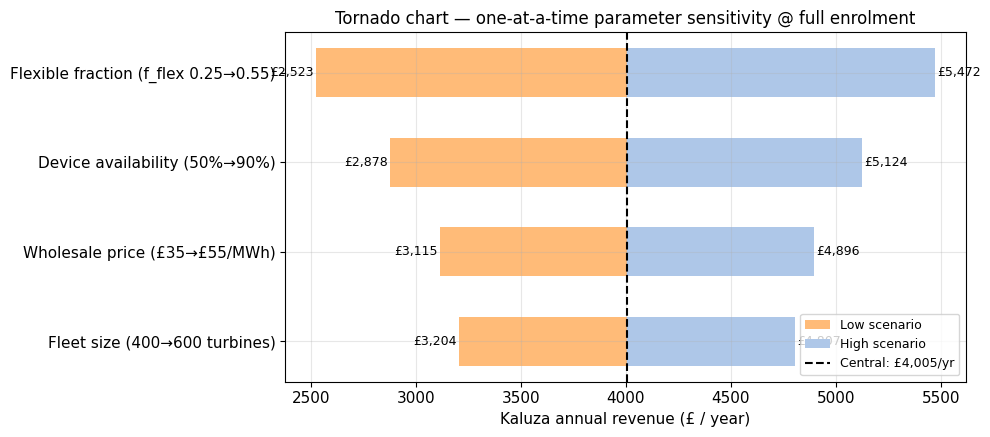

In [22]:
# --- Tornado: one-at-a-time sensitivity, Kaluza revenue £/yr @ full enrolment ---
def avoided_at(ff=F_FLEX, av=AVAILABILITY):
    df_f = build_flexible_demand(demand_all, f_flex=ff)
    _, a, _ = supply_demand_match(supply_30, df_f, N_HOUSEHOLDS_ORKNEY, availability=av)
    return a

rev_central = kaluza_annual_revenue(full_avoided)

tornado_specs = [
    (f"Flexible fraction (f_flex {F_FLEX_LOW}→{F_FLEX_HIGH})",
     kaluza_annual_revenue(avoided_at(ff=F_FLEX_LOW)),
     kaluza_annual_revenue(avoided_at(ff=F_FLEX_HIGH))),
    (f"Device availability ({AVAIL_LOW:.0%}→{AVAIL_HIGH:.0%})",
     kaluza_annual_revenue(avoided_at(av=AVAIL_LOW)),
     kaluza_annual_revenue(avoided_at(av=AVAIL_HIGH))),
    (f"Wholesale price (£{WHOLESALE_LOW:.0f}→£{WHOLESALE_HIGH:.0f}/MWh)",
     kaluza_annual_revenue(full_avoided, price=WHOLESALE_LOW),
     kaluza_annual_revenue(full_avoided, price=WHOLESALE_HIGH)),
    ("Fleet size (400→600 turbines)",
     kaluza_annual_revenue(full_avoided * (400 / N_TURBINES)),
     kaluza_annual_revenue(full_avoided * (600 / N_TURBINES))),
]

tornado_df = pd.DataFrame(
    [{"driver": d, "low": lo, "high": hi, "range": hi - lo}
     for d, lo, hi in tornado_specs]
).sort_values("range").reset_index(drop=True)

from matplotlib.patches import Patch
import matplotlib.lines as mlines

fig, ax = plt.subplots(figsize=(10, 4.5))
for i, row in tornado_df.iterrows():
    ax.barh(i, row["high"] - rev_central, left=rev_central, color="#aec7e8", height=0.55)
    ax.barh(i, row["low"] - rev_central,  left=rev_central, color="#ffbb78", height=0.55)
    ax.text(row["high"] + 12, i, f'£{row["high"]:,.0f}', va="center", fontsize=9)
    ax.text(row["low"] - 12,  i, f'£{row["low"]:,.0f}',  va="center", fontsize=9, ha="right")

ax.axvline(rev_central, color="black", linewidth=1.5, linestyle="--")
ax.set_yticks(range(len(tornado_df)))
ax.set_yticklabels(tornado_df["driver"])
ax.set_xlabel("Kaluza annual revenue (£ / year)")
ax.set_title("Tornado chart — one-at-a-time parameter sensitivity @ full enrolment")
ax.legend(
    handles=[
        Patch(facecolor="#ffbb78", label="Low scenario"),
        Patch(facecolor="#aec7e8", label="High scenario"),
        mlines.Line2D([], [], color="black", linestyle="--",
                      label=f"Central: £{rev_central:,.0f}/yr"),
    ],
    loc="lower right", fontsize=9
)
plt.tight_layout()
plt.show()


Wholesale price (£35–£55/MWh) has the widest impact because it scales revenue linearly. Flexibility fraction and device availability have a narrower effect: since residential demand is the binding constraint, even large swings in these parameters produce only modest changes in avoided MWh. Fleet size scales proportionally, as expected from the single-turbine approach. Under no scenario does Kaluza approach break-even on residential curtailment value alone — this is a structural limit, not a result of conservative assumptions.


# Discussion

In [23]:
summary_df = pd.DataFrame({
    "Question": ["Curtailed (GWh/yr)", "Avoided @ 100% pen. (MWh/yr)",
                 "Recovery @ 100% pen.", "Number of homes for 25% DR penetration",
                 "Kaluza revenue @ 100% pen. (£/yr)"],
    "Result": [
        f"{gwh_fleet:.2f}",
        f"{full_avoided:.0f}",
        f"{100 * full_avoided / mwh_fleet:.2f}%",
        f"{int(q3_df.loc[q3_df['dr_penetration_target']=='25%', 'households_on_scheme'].iloc[0]):,}",
        f"{rev_central:,.0f}",
    ],
})
display(summary_df)

,Question,Result
0,Curtailed (GWh/yr),76.86
1,Avoided @ 100% pen. (MWh/yr),267
2,Recovery @ 100% pen.,0.35%
3,Number of homes for 25% DR penetration,"2,596"
4,Kaluza revenue @ 100% pen. (£/yr),"4,005"


This analysis shows that wind curtailment in Orkney is both substantial and persistent under 
current network conditions. Estimated curtailed generation reaches approximately **77 GWh per 
year**, confirming that constrained renewable output represents a significant operational and 
economic issue for the local energy system.

The results also show that curtailment is highly concentrated during periods of strong wind 
generation and low local demand, creating favourable conditions for flexible demand response. 
However, a clear scale mismatch emerges between available curtailed energy and the realistic 
flexibility provided by residential electric heating alone. Even under optimistic 
full-participation assumptions, the Heat Smart Orkney (HSO) model recovers only around 
**267.3 MWh per year**, representing less than **1%** of annual curtailment we estimate at **76.86 GWh**.

The four initial hypotheses are therefore broadly supported:

| Hypothesis                                                         | Conclusion                                                                                              |
| ------------------------------------------------------------------ | ------------------------------------------------------------------------------------------------------- |
| **Material curtailment exists**                               | Supported. Curtailment volumes are sufficiently large to justify commercial and regulatory attention.   |
| **Curtailment is temporally concentrated**                    | Supported. Curtailment occurs during a limited number of high-intensity periods.                        |
| **Residential demand response can recover curtailed energy**  | Supported, but quantitatively limited relative to total curtailed generation.                           |
| **Turbine power follows a non-linear saturating power curve** | Supported. The validated power curve provides a credible basis for estimating unconstrained generation. |

These findings directly address the research question. Residential demand response through HSO 
can mitigate only a marginal share of Orkney curtailment: approximately **0.35% of annual 
curtailed energy** under central assumptions and full enrolment. The associated economic value 
unlocked at that scale is correspondingly modest: Kaluza's estimated revenue share reaches 
approximately **£3,007 per year** at full penetration under current wholesale price assumptions, 
a figure that falls well short of covering programme costs without subsidy or external funding. 
Household-level benefits remain similarly limited in absolute terms, though the per-MWh bill 
saving is meaningful for participating homes.

Residential demand response should therefore not be positioned as a curtailment-elimination 
solution. Its strategic value lies in demonstrating flexible demand orchestration at scale and 
establishing the operational infrastructure for broader smart-grid services. Materially reducing 
system-wide curtailment would require additional flexible assets (electric vehicles, batteries, 
industrial demand response or network reinforcement) beyond the residential heating scope of 
the current programme.

From a commercial perspective, the most credible near-term path for Kaluza is a targeted pilot 
deployment focused on highly flexible storage-heater households during peak winter curtailment 
periods. This would allow validation of real-world customer responsiveness, dispatch reliability 
and operational flexibility at manageable cost. Achieving programme viability at scale will 
additionally require partnerships with grid operators or renewable generators, as the business 
case cannot be sustained on residential participation economics alone.

# Limitations and Future Work

Several limitations affect the precision and generalisability of this analysis.

First, data quality issues were identified in parts of the dataset, particularly during 
September, where missing or inconsistent observations required cleaning and 
filtering. Curtailment estimates therefore remain sensitive to the reliability of the 
underlying measurements and to the limited historical period analysed. The fleet-wide 
figure is additionally derived by scaling a single turbine by 500, which does not account 
for differences in turbine type, age, location or maintenance status across the Orkney 
fleet. Curtailment is also identified solely through the setpoint signal (`setpoint < 891 kW`).
Grid-driven output reductions occurring without a corresponding setpoint change would not 
be captured, meaning the annual curtailed energy estimate is likely a lower bound rather than a precise 
system-level accounting.

Second, the modelling framework relies on simplifying assumptions. Although the turbine 
power curve was empirically validated, actual turbine output may vary due to wake effects, 
maintenance, ageing or environmental conditions. The demand-response matching approach 
uses aggregate half-hourly flexibility profiles and does not model the thermal storage 
duration of individual heating systems, rebound effects following a dispatch event or 
intra-hour timing mismatches that would occur in real-time operation. Similarly, the 
residential flexibility model assumes fixed flexibility parameters, whereas real consumption 
patterns depend on occupancy, comfort preferences, weather sensitivity and participation 
compliance.

Third, the scope of flexibility considered is intentionally narrow. The analysis models 
residential electric heating only and excludes other potentially important flexible assets 
such as electric vehicles, batteries, commercial demand response or utility-scale storage. 
Avoided curtailment figures should therefore be interpreted as an upper bound on what a 
residential-only programme could deliver under idealised dispatch conditions, rather than 
as a reflection of the total flexibility potential of the Orkney energy system.

Finally, the economic assessment depends on uncertain assumptions regarding electricity 
prices, avoided-curtailment value, installation costs and regulatory incentives. The 
commercial viability of demand response may therefore vary significantly under different 
market or policy conditions.

Several directions for future work follow naturally from these limitations. Extending the 
framework to include additional flexibility assets would provide a more realistic 
system-level assessment of smart-grid potential. Future studies could also replace the 
rule-based matching approach with optimisation-based control methods capable of accounting 
for uncertainty in generation, demand and pricing.

Another important extension would be the inclusion of network-level constraints such as 
voltage limits, transformer loading and feeder congestion. Coupling the demand-response 
model with power-system simulation tools would improve the engineering realism of the 
analysis.

Finally, the highest-priority next step is the collection of real pilot data. Measuring 
actual household flexibility, customer engagement, rebound effects and long-term 
behavioural response would significantly strengthen future operational and commercial 
assessments.

# References

Emergya Wind Technologies (n.d.) *DW54-900 Technical Specifications*. Emergya Wind Technologies BV. https://ewtdirectwind.com/products/dw54/.


Kaluza and Community Energy Scotland (2024) *Heat Smart Orkney: Case Details*. [Industry project brief, Analytics in Business module, Imperial College Business School].

*Module supplementary material* (2024) *Energy Brief: Turbine Telemetry and Residential Demand Data*. Analytics in Business, Imperial College Business School.

*Module supplementary material* (2024) *Heat Smart Orkney Frequently Asked Questions*. Analytics in Business, Imperial College Business School. 